#### 1.对比1

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random
import time

# ==========================================
# 0. 全局配置
# ==========================================

# 图像大小设置 (宽, 高)
FIG_SIZE = (22, 10) 

# 是否显示箱内的散点
SHOW_INNER_DOTS = False
# SHOW_INNER_DOTS = True

# 是否绘制 Q-Error 图
SHOW_Q_ERROR_PLOT = False

# --- [关键修改] 随机种子设置 ---
RANDOM_SEED = 62225 
# RANDOM_SEED = None 

# 采样设置 (None 为使用全部)
SAMPLE_SIZE = 20

# 方法显示的顺序 (不在列表中的将被过滤掉)
METHOD_ORDER = [
    # 'baseline_graph_only', 
    'UN', 
    'PO', 
    'MAB', 
    'FOIS_nrs', 
    'FOIS_rs', 
    'POSS', 
] 

# METHOD_ORDER = [
#     'baseline_graph_only', 
#     'baseline_uniform', 
#     'baseline_proxy', 
#     'baseline_proxy_a', 
#     'baseline_proxy_a_unbiased_test1', 
#     'proxyE_importance', 
# ] 

# 箱型图颜色主题
BOX_PALETTE = "Set3"

# ==========================================
# 1. 种子应用逻辑
# ==========================================
if RANDOM_SEED is not None:
    print(f"[CONFIG] 检测到固定随机种子: {RANDOM_SEED} -> 采样结果将固定不变。")
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED) 
else:
    print(f"[CONFIG] 随机种子为 None -> 每次采样结果将不同。")

# ==========================================
# 2. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            
            # --- 提取查询名称 ---
            if 'query_basename' in tmp.columns:
                tmp['query_identifier'] = tmp['query_basename'].astype(str).apply(
                    lambda x: x.replace('.graph', '')
                )
            elif 'query_index' in tmp.columns:
                tmp['query_identifier'] = "idx_" + tmp['query_index'].astype(str)
            else:
                tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            
            if 'T_true' not in tmp.columns or 'T_hat' not in tmp.columns:
                continue

            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    existing_methods = set(df[method_col].unique())
    
    # [修改] 严格根据 METHOD_ORDER 筛选分析对象
    if METHOD_ORDER:
        # 只保留既在 METHOD_ORDER 中，又存在于数据中的方法
        methods_to_analyze = [m for m in METHOD_ORDER if m in existing_methods]
        # 注意：这里删除了之前 extend(remain) 的逻辑
    else:
        methods_to_analyze = sorted(list(existing_methods))

    for method in methods_to_analyze:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            
            top_n = outliers.head(15)
            for idx, row in top_n.iterrows():
                print(f"  - Query: {str(row[id_col]):<40} | Val: {row[metric_col]:.4f}")
                
            if len(outliers) > 15:
                print(f"  ... 还有 {len(outliers)-15} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制图表
    """
    if df.empty:
        return

    # [修改] 1. 绘图前先过滤数据：只保留 METHOD_ORDER 中的方法
    if METHOD_ORDER:
        # 过滤 DataFrame，仅保留 method 在 METHOD_ORDER 中的行
        df = df[df["method"].isin(METHOD_ORDER)].copy()
        
        if df.empty:
            print("[WARN] 过滤后数据为空，请检查 METHOD_ORDER 是否与数据中的 method 名称匹配。")
            return

    # 先分析异常值（此时 df 已经是过滤后的了）
    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    # [修改] 2. 确定绘图顺序
    available_methods = set(df["method"].unique())
    
    if METHOD_ORDER:
        # 严格按照 METHOD_ORDER 排序，且只包含数据中存在的
        final_order = [m for m in METHOD_ORDER if m in available_methods]
    else:
        final_order = sorted(list(available_methods))

    sns.set_theme(style="whitegrid", font_scale=1.2)
    
    # --- 根据配置决定子图数量 ---
    if SHOW_Q_ERROR_PLOT:
        fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
        ax1 = axes[0]
        ax2 = axes[1]
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=FIG_SIZE)
        ax2 = None

    palette_dots = {"Over": "red", "Under": "blue"}
    
    # --- 核心辅助函数：只画须内部的点 ---
    def plot_inner_strips(ax, data, x_col, y_col, order_list):
        if not SHOW_INNER_DOTS:
            return

        # 只使用 final_order 中的方法
        current_methods = order_list 
        inner_data_list = []
        
        for m in current_methods:
            sub = data[data[x_col] == m]
            if sub.empty: continue
            
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, 
                order=order_list,
                jitter=0.25,  
                dodge=False,  
                alpha=0.6, size=4, ax=ax, legend=False 
            )

    # ==========================
    # 图1：Relative Error
    # ==========================
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        hue="method", palette=BOX_PALETTE, dodge=False,
        order=final_order, # 使用过滤后的顺序
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, 
        whis=1.5,
        ax=ax1
    )
    plot_inner_strips(ax1, df, "method", "signed_relative_error", final_order)
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.0, 1.0) 
    ax1.tick_params(axis='x', rotation=30)
    if ax1.get_legend(): ax1.get_legend().remove()
    
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # ==========================
    # 图2：Log Signed Q-Error (按需)
    # ==========================
    if SHOW_Q_ERROR_PLOT and ax2 is not None:
        sns.boxplot(
            data=df, x="method", y="log_signed_q_error",
            hue="method", palette=BOX_PALETTE, dodge=False,
            order=final_order,
            showmeans=True, width=0.6,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
            whis=1.5,
            ax=ax2
        )
        plot_inner_strips(ax2, df, "method", "log_signed_q_error", final_order)

        ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
        for i in [1, 2, 3]:
            ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            
        ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
        ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
        ax2.set_ylim(-6, 6)
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
        ax2.tick_params(axis='x', rotation=30)
        if ax2.get_legend(): ax2.get_legend().remove()
        
        ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
                 fontsize=12, fontweight='bold', verticalalignment='top',
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # 图例
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='Outlier')]
    if SHOW_INNER_DOTS:
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Under (Inner)'))
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Over (Inner)'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置与执行
# ==========================================
# dataset_name = "dataset_one" 
dataset_name = "dataset_three3" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置

proxy_models = [
    # 'ML1_proxy4b_probability',
    # 'ML1_proxy2b_probability_ML2_proxy1_probability',
    'ML1_proxy4b_probability_ML2_proxy1_probability',
    # 'ML1_proxy4b_probability',
    # 'Dist_Beta_U_proxy2',
    # 'Dist_Asym_LeftHigh_proxy2',
    # 'Dist_Asym_RightHigh_proxy2',

    
    # # # 'Dist_Bimodal_proxy2',
    # 'Dist_Bimodal_left_proxy2',
    # 'Dist_Bimodal_right_proxy2',

    # 'Dist_SkewHigh_proxy2',
    # 'Dist_SkewLow_proxy2',

    # 'Dist_Extreme_Mix_proxy2',

]
print(f"[INFO] 图像尺寸: {FIG_SIZE}")
print(f"[INFO] 是否绘制 Q-Error 图: {SHOW_Q_ERROR_PLOT}")
print(f"[INFO] 随机种子: {RANDOM_SEED}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        # 不同的种子或不同的采样，结合时间戳，文件不会冲突，且可追溯
        save_path = os.path.join(summarys_dir, f"{dataset_name}_metrics_analysis_{timestamp}.png")
        
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

#### 2. 对比2

正在从目录中随机抽取 10 个 Baseline 文件...
已选中 Baseline 文件: ['results_summary_run_20.csv', 'results_summary_run_2.csv', 'results_summary_run_13.csv', 'results_summary_run_6.csv', 'results_summary_run_7.csv', 'results_summary_run_4.csv', 'results_summary_run_8.csv', 'results_summary_run_3.csv', 'results_summary_run_9.csv', 'results_summary_run_10.csv']
Baseline 数据加载完成，共 50880 行。
正在读取 FaSTestO: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/results_summary_FaSTestO.csv
正在标准化 query_basename...
FaSTestO   查询数: 246
Baseline   查询数 (Unique): 246
==> 最终交集查询数: 246
最大绝对相对误差 (Max ARE): 4.04


/tmp/ipykernel_1721163/4224581954.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,


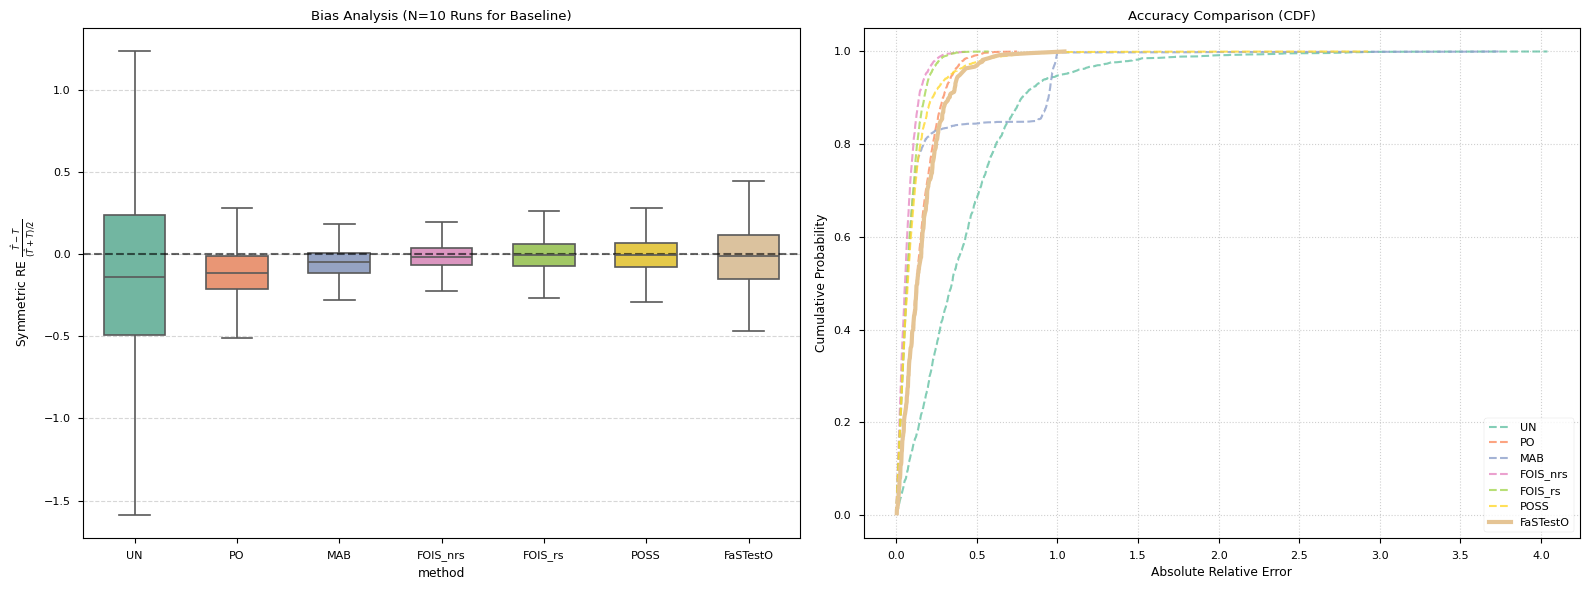

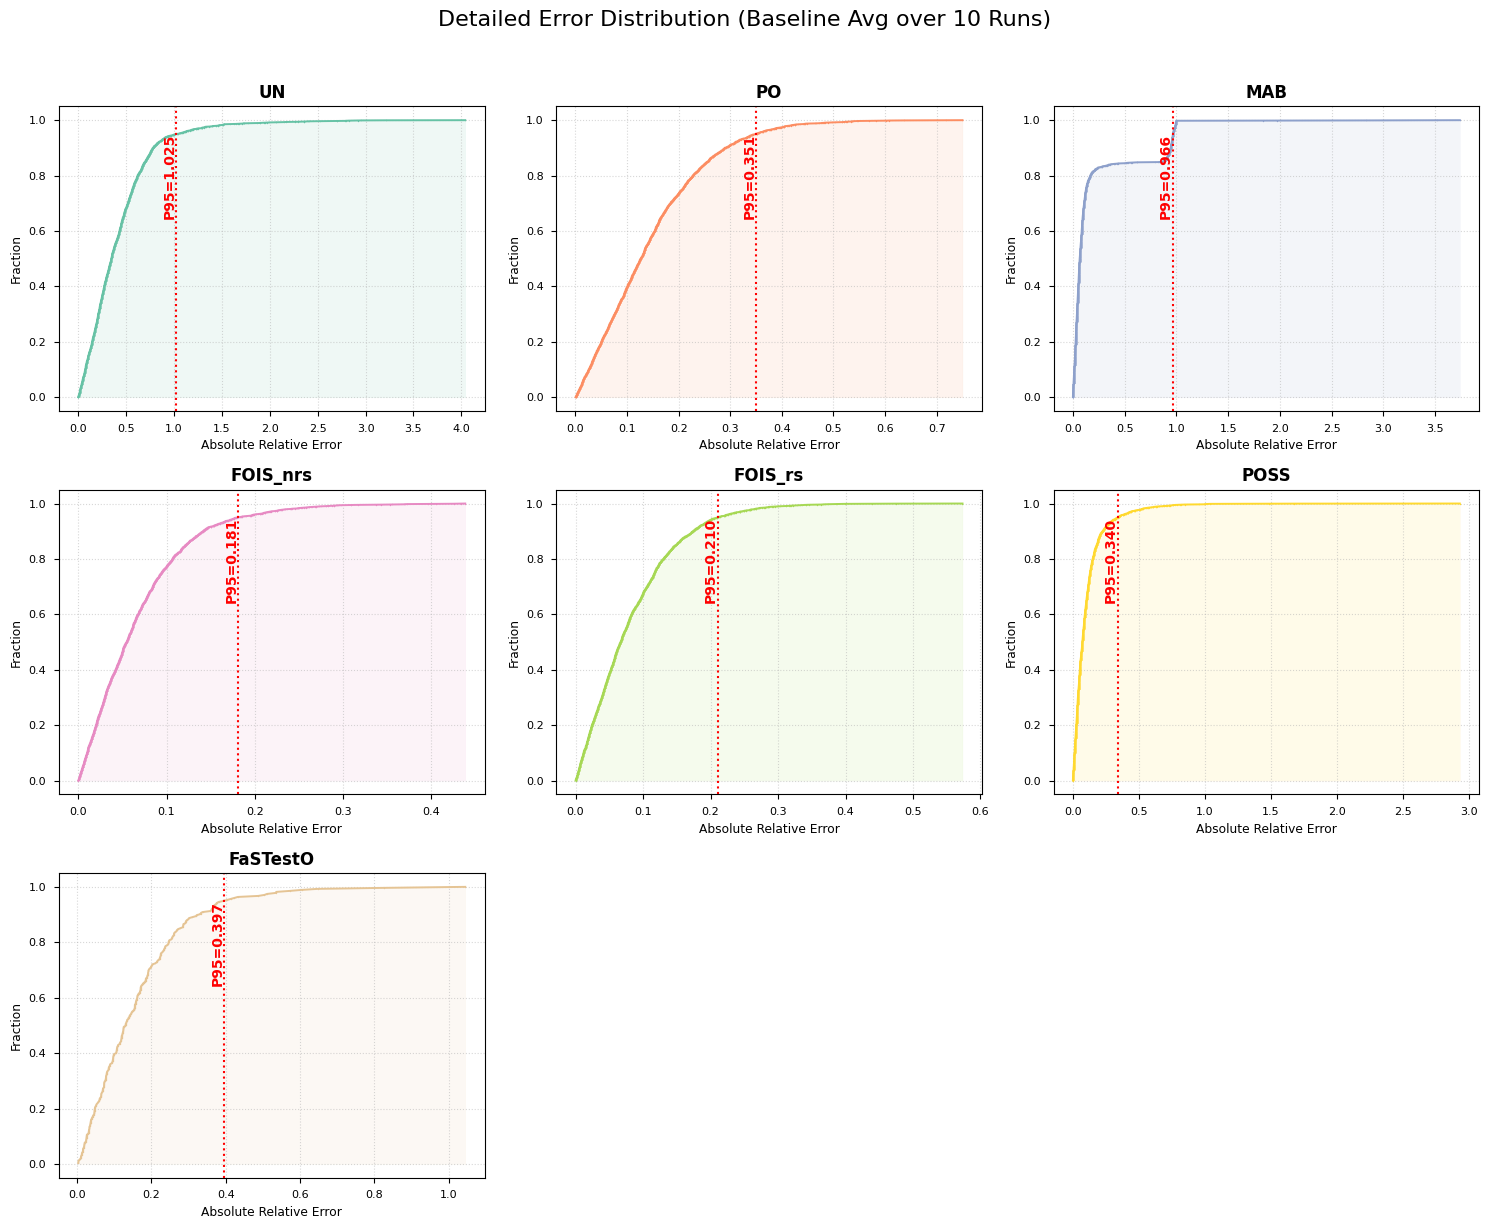


       AQP Evaluation Metrics Summary
Method               | Mean       | Median     | P95        | Max       
----------------------------------------------------------------------
UN                   |  41.96%    |  34.53%    | 102.47%    | 404.07%
PO                   |  14.54%    |  12.62%    |  35.08%    |  75.01%
MAB                  |  20.79%    |   6.61%    |  96.63%    | 373.72%
FOIS_nrs             |   6.85%    |   5.47%    |  18.14%    |  43.83%
FOIS_rs              |   8.26%    |   6.68%    |  21.04%    |  57.33%
POSS                 |  10.79%    |   7.20%    |  34.01%    | 292.84%
FaSTestO             |  16.23%    |  13.10%    |  39.68%    | 104.39%
----------------------------------------------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math
import random

# ==========================================
# 1. 配置路径与采样设置
# ==========================================
# Distribution = 'ML1_proxy4b_probability_ML2_proxy1_probability'
Distribution = 'ML1_proxy4b_probability'
dataset = 'dataset_three'
fatestO_file = 'results_summary_FaSTestO.csv'

# --- [用户配置区] 是否启用对比 ---
# ENABLE_WANDERJOIN = True   # 是否包含 WanderJoin 结果
ENABLE_WANDERJOIN = False   # 是否包含 WanderJoin 结果
ENABLE_FASTESTO = False     # 是否包含 FaSTestO 结果
SHOW_ALL_POINTS = False    
SHOW_OUTLIERS = False  
# --- 采样设置 ---
N_SAMPLES = 10  # 随机选取多少个 Baseline run 文件参与计算

# --- 路径配置 ---
path_wj = f"/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_multi_{dataset}.csv"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO_file}"
baseline_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys/{Distribution}/"

# 方法定义
methods_wj = ['WJ_uniform_multi', 'WJ_importance_multi']
methods_baseline = ['FOIS_nrs', 'FOIS_rs', 'POSS','UN','PO','MAB']
final_order = ['WJU', 'WJP', 'UN','PO','MAB', 'FOIS_nrs', 'FOIS_rs', 'POSS', 'FaSTestO']

# ==========================================
# 2. 数据加载与预处理
# ==========================================

# --- 2.1 加载 Baseline (必须存在) ---
if not os.path.exists(baseline_dir):
    print(f"[Error] Baseline 目录不存在: {baseline_dir}")
    exit()

print(f"正在从目录中随机抽取 {N_SAMPLES} 个 Baseline 文件...")
all_files = [f for f in os.listdir(baseline_dir) if f.startswith("results_summary_run_") and f.endswith(".csv")]

if len(all_files) == 0:
    print("[Error] Baseline 目录下没有找到 results_summary_run_*.csv 文件")
    exit()

if len(all_files) < N_SAMPLES:
    print(f"[Warning] 目录下只有 {len(all_files)} 个文件，少于要求的 {N_SAMPLES}，将全部使用。")
    selected_files = all_files
else:
    selected_files = random.sample(all_files, N_SAMPLES)
print(f"已选中 Baseline 文件: {selected_files}")

df_base_list = []
for f in selected_files:
    path = os.path.join(baseline_dir, f)
    try:
        temp_df = pd.read_csv(path)
        df_base_list.append(temp_df)
    except Exception as e:
        print(f"读取文件 {f} 失败: {e}")

if not df_base_list:
    print("[Error] 无法读取任何 Baseline 文件，程序终止。")
    exit()

df_base_raw = pd.concat(df_base_list, ignore_index=True)
print(f"Baseline 数据加载完成，共 {len(df_base_raw)} 行。")

# --- 2.2 加载 WanderJoin (可选) ---
df_wj_raw = None
if ENABLE_WANDERJOIN:
    if os.path.exists(path_wj):
        print(f"正在读取 WanderJoin: {path_wj}")
        df_wj_raw = pd.read_csv(path_wj)
    else:
        print(f"[Warning] 启用 WanderJoin 但文件不存在，跳过: {path_wj}")

# --- 2.3 加载 FaSTestO (可选) ---
df_fast_raw = None
if ENABLE_FASTESTO:
    if os.path.exists(path_fastesto):
        print(f"正在读取 FaSTestO: {path_fastesto}")
        df_fast_raw = pd.read_csv(path_fastesto)
    else:
        print(f"[Warning] 启用 FaSTestO 但文件不存在，跳过: {path_fastesto}")

# -----------------------------------------------------------
# 标准化文件名 (去除 .graph 后缀)
# -----------------------------------------------------------
print("正在标准化 query_basename...")

# 定义一个帮助函数来处理
def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

df_base_raw = standardize_name(df_base_raw)
df_wj_raw = standardize_name(df_wj_raw)
df_fast_raw = standardize_name(df_fast_raw)

# -----------------------------------------------------------
# 动态提取交集 (Dynamic Intersection)
# -----------------------------------------------------------
# 基础集合：Baseline 的查询
common_queries = set(df_base_raw['query_basename'].unique())

if df_wj_raw is not None:
    qs_wj = set(df_wj_raw['query_basename'].unique())
    common_queries = common_queries.intersection(qs_wj)
    print(f"WanderJoin 查询数: {len(qs_wj)}")

if df_fast_raw is not None:
    qs_fast = set(df_fast_raw['query_basename'].unique())
    common_queries = common_queries.intersection(qs_fast)
    print(f"FaSTestO   查询数: {len(qs_fast)}")

print(f"Baseline   查询数 (Unique): {len(df_base_raw['query_basename'].unique())}")
print(f"==> 最终交集查询数: {len(common_queries)}")

if len(common_queries) == 0:
    print("[Error] 交集为空，无法进行对比！")
else:
    # -----------------------------------------------------------
    # 数据过滤与合并
    # -----------------------------------------------------------
    df_combined_list = []

    # 1. 处理 Baseline
    df_base = df_base_raw[df_base_raw['query_basename'].isin(common_queries)].copy()
    df_base = df_base[df_base['method'].isin(methods_baseline)].copy()
    
    # 建立 GT 映射 (从 Baseline 获取)
    truth_map = df_base[['query_basename', 'T_true']]\
        .drop_duplicates(subset=['query_basename'])\
        .set_index('query_basename')['T_true']\
        .to_dict()
    
    # 过滤有效的 GT
    valid_queries = {q for q, t in truth_map.items() if t > 0 and not pd.isna(t)}
    
    # 重新过滤 Baseline 并加入列表
    df_base = df_base[df_base['query_basename'].isin(valid_queries)].copy()
    df_base['T_true'] = df_base['query_basename'].map(truth_map)
    df_combined_list.append(df_base[['method', 'T_hat', 'T_true']])

    # 2. 处理 WanderJoin (如果存在)
    if df_wj_raw is not None:
        df_wj = df_wj_raw[df_wj_raw['query_basename'].isin(valid_queries)].copy()
        df_wj = df_wj[df_wj['method'].isin(methods_wj)].copy()
        # 改名
        df_wj['method'] = df_wj['method'].replace({
            'WJ_uniform_multi': 'WJU', 
            'WJ_importance_multi': 'WJP'
        })
        df_wj['T_true'] = df_wj['query_basename'].map(truth_map)
        df_combined_list.append(df_wj[['method', 'T_hat', 'T_true']])

    # 3. 处理 FaSTestO (如果存在)
    if df_fast_raw is not None:
        df_fast = df_fast_raw[df_fast_raw['query_basename'].isin(valid_queries)].copy()
        df_fast['method'] = 'FaSTestO'
        df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
        df_combined_list.append(df_fast[['method', 'T_hat', 'T_true']])

    # 合并
    df_all = pd.concat(df_combined_list, ignore_index=True)

    # ==========================================
    # 3. 计算误差
    # ==========================================
    epsilon = 1e-9 
    df_all['SymRE'] = (df_all['T_hat'] - df_all['T_true']) / (0.5 * (df_all['T_hat'] + df_all['T_true']) + epsilon)
    df_all['ARE'] = (df_all['T_hat'] - df_all['T_true']).abs() / (df_all['T_true'] + epsilon)

    max_are = df_all['ARE'].max()
    USE_LOG_SCALE = max_are > 5.0 
    print(f"最大绝对相对误差 (Max ARE): {max_are:.2f}")

    if USE_LOG_SCALE:
        df_all['PlotValue'] = np.maximum(df_all['ARE'], 1e-4)
        x_label_cdf = "Absolute Relative Error (Log Scale)"
    else:
        df_all['PlotValue'] = df_all['ARE']
        x_label_cdf = "Absolute Relative Error"

    # 动态生成绘图顺序 (只包含实际存在的方法)
    plot_order = [m for m in final_order if m in df_all['method'].unique()]
    
    # 颜色配置
    colors = sns.color_palette("Set2", n_colors=len(plot_order))
    method_colors = dict(zip(plot_order, colors))

    # ==========================================
    # 4. 绘图 Part 1: Bias + CDF
    # ==========================================    

    plt.style.use('seaborn-v0_8-paper')
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Boxplot
    sns.boxplot(x="method", y="SymRE", data=df_all, order=plot_order,
                ax=axes[0], palette=method_colors, 
                showfliers=SHOW_OUTLIERS, width=0.6, linewidth=1.2)
    
    if SHOW_ALL_POINTS:
        df_all['EstimationType'] = df_all['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(x="method", y="SymRE", data=df_all, order=plot_order,
                      ax=axes[0], hue="EstimationType", 
                      palette={'High': 'red', 'Low': 'blue'},
                      size=2.0, alpha=0.3, jitter=True, dodge=False, legend=False)

    axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    axes[0].set_title(f"Bias Analysis (N={N_SAMPLES} Runs for Baseline)")
    axes[0].set_ylabel(r"Symmetric RE $\frac{\hat{T} - T}{(\hat{T} + T)/2}$")
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

    # CDF
    for method in plot_order:
        subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
        if subset.empty: continue
        y_vals = np.arange(1, len(subset) + 1) / len(subset)
        
        lw = 3.0 if method == 'FaSTestO' else 1.5
        ls = '-' if method == 'FaSTestO' else '--'
        alpha = 1.0 if method == 'FaSTestO' else 0.8
        
        axes[1].plot(subset, y_vals, label=method, color=method_colors[method], 
                     linewidth=lw, linestyle=ls, alpha=alpha)

    axes[1].set_title("Accuracy Comparison (CDF)")
    axes[1].set_xlabel(x_label_cdf)
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].legend(loc='lower right')
    axes[1].grid(True, which="both", linestyle=':', alpha=0.6)
    if USE_LOG_SCALE: axes[1].set_xscale('log')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. 绘图 Part 2: Detailed Subplots
    # ==========================================
    cols = min(len(plot_order), 3)
    if cols > 0:
        rows = math.ceil(len(plot_order) / cols)    
        fig2 = plt.figure(figsize=(5 * cols, 4 * rows))
        fig2.suptitle(f"Detailed Error Distribution (Baseline Avg over {N_SAMPLES} Runs)", fontsize=16, y=1.02)
        target_percentiles = [0.95] 

        for idx, method in enumerate(plot_order):
            ax = plt.subplot(rows, cols, idx + 1)
            subset = df_all[df_all['method'] == method]['PlotValue'].sort_values()
            if subset.empty: continue
            
            y_vals = np.arange(1, len(subset) + 1) / len(subset)
            color = method_colors[method]
            
            ax.plot(subset, y_vals, marker='.', markersize=2, linestyle='-', color=color)
            ax.fill_between(subset, y_vals, color=color, alpha=0.1)
            
            for p in target_percentiles:
                p_val = subset.quantile(p)
                ax.axvline(p_val, color='red', linestyle=':', linewidth=1.5)
                ax.text(p_val, p, f"P{int(p*100)}={p_val:.3f}", 
                        rotation=90, color='red', fontsize=10, fontweight='bold',
                        verticalalignment='top', horizontalalignment='right')

            ax.set_title(f"{method}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label_cdf)
            ax.set_ylabel("Fraction")
            ax.grid(True, which="both", linestyle=':', alpha=0.5)
            if USE_LOG_SCALE: ax.set_xscale('log')

        plt.tight_layout()
        plt.show()

    # ==========================================
    # 6. 表格输出
    # ==========================================
    print("\n" + "="*50)
    print("       AQP Evaluation Metrics Summary")
    print("="*50)
    
    summary_table = df_all.groupby('method')['ARE'].agg(
        Mean_ARE='mean', Median_ARE='median',
        P95_ARE=lambda x: x.quantile(0.95), Max_ARE='max'
    )
    existing_methods = [m for m in final_order if m in summary_table.index]
    summary_table = summary_table.loc[existing_methods]
    
    print(f"{'Method':<20} | {'Mean':<10} | {'Median':<10} | {'P95':<10} | {'Max':<10}")
    print("-" * 70)
    for method in existing_methods:
        row = summary_table.loc[method]
        print(f"{method:<20} | {row['Mean_ARE']*100:6.2f}%    | {row['Median_ARE']*100:6.2f}%    | {row['P95_ARE']*100:6.2f}%    | {row['Max_ARE']*100:6.2f}%")
    print("-" * 70)

### 3. 消融实验最终版

1). 运行四种基线代码:


🚀 开始处理数据集: dataset_three

[*] 正在加载数据集: dataset_three | alloc_suffix=sum | truth_suffix=sum
✅ 已从 JSON 加载了 246 条 Ground Truth 数据
[Warn] FOIS 文件缺失: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/efficiency/FOIS_rs_FOSS_nrs_budget_curve_fast.csv
[*] 正在绘制误差收敛曲线...
✅ 收敛图已保存至: /home/wangshuo/resource/paper_figuires/time_parler_post_ablation.pdf


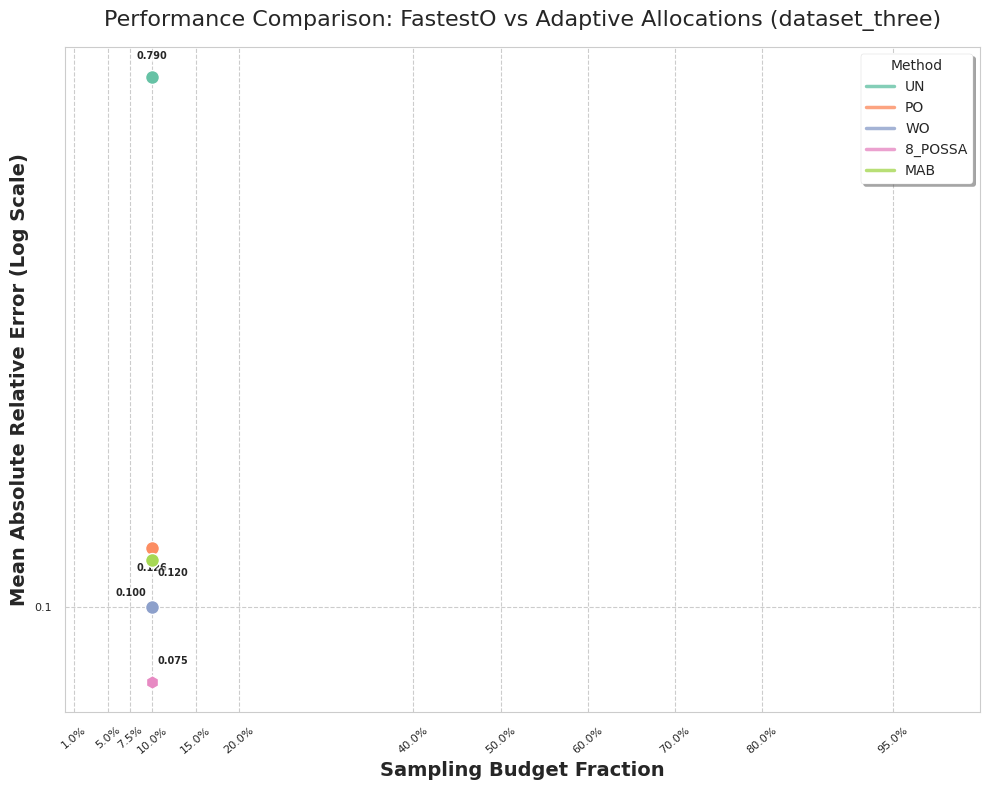


       Summary of Mean ARE (Pivot Table) - dataset_three
method          UN     PO     WO  8_POSSA    MAB
budget_frac                                     
0.0100         NaN    NaN    NaN      NaN    NaN
0.0500         NaN    NaN    NaN      NaN    NaN
0.0750         NaN    NaN    NaN      NaN    NaN
0.1000      0.7900 0.1262 0.1002   0.0747 0.1205
0.1500         NaN    NaN    NaN      NaN    NaN
0.2000         NaN    NaN    NaN      NaN    NaN
0.3000         NaN    NaN    NaN      NaN    NaN
0.4000         NaN    NaN    NaN      NaN    NaN
0.5000         NaN    NaN    NaN      NaN    NaN
0.6000         NaN    NaN    NaN      NaN    NaN
0.7000         NaN    NaN    NaN      NaN    NaN
0.8000         NaN    NaN    NaN      NaN    NaN
0.9000         NaN    NaN    NaN      NaN    NaN

[*] 正在为 Budget=0.1 绘制 VLDB 规范的箱型图...


/tmp/ipykernel_2082990/3332494109.py:338: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


✅ VLDB 规范箱型图已保存至: /home/wangshuo/resource/paper_figuires/box_parler_post_ablation.pdf


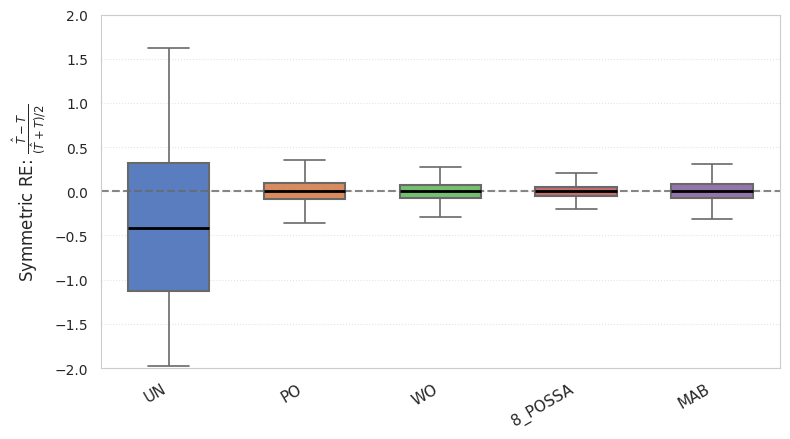


✅ 所有图表均已按照 VLDB 标准导出完成。


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

# ==========================================
# 0. 全局配置与 VLDB 出版级样式定义
# ==========================================
try:
    plt.style.use('seaborn-v0_8-paper')
except:
    plt.style.use('seaborn-paper')

# 强制要求：确保 PDF 导出时字体被嵌入为 TrueType (Type 42)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DESIRED_ORDER =[
    "UN",
    "PO",
    "WO",
    "8_POSSA",
    "MAB"
]

# 统一使用 Set2 调色板
PALETTE = sns.color_palette("Set2", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

MARKER_DICT = {
    "FOIS_nrs": "o",
    "8_POSSA": "h",
    "FastestO": "s",  # 为 FastestO 指定特定 marker
    "Exact_structureO": "^",
}

OFFSET_MAP = {
    "UN": (0, 15),       # 往上偏
    "PO": (0, -15),      # 往下偏
    "WO": (-15, 10),     # 往左上偏
    "MAB": (15, -10),    # 往右下偏
    "8_POSSA": (15, 15), # 往右上偏
}

# ==========================================
# 1. 数据加载与处理函数
# ==========================================
def load_and_process_data(dataset_name, base_dir,alloc_suffix="", truth_suffix=""):
    """
    读取 CSV 文件，清洗数据，从指定 JSON 路径加载 Ground Truth，计算 ARE 和 SymRE。
    """
    
    print(f"\n[*] 正在加载数据集: {dataset_name} | alloc_suffix={alloc_suffix} | truth_suffix={truth_suffix}")
    def with_suffix(prefix, suffix, ext):
        return f"{prefix}_{suffix}{ext}" if suffix else f"{prefix}{ext}"

    path_alloc_new = os.path.join(base_dir, "allocation_strategy_comparison_ablation.csv")
    # path_alloc_new = os.path.join(
    #     base_dir, with_suffix("allocation_strategy_comparison", alloc_suffix, ".csv")
    # )

    # path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
    path_fast = os.path.join(
        base_dir, with_suffix("FastestO_budget_curve", alloc_suffix, ".csv")
    )

    path_exact = os.path.join(
        base_dir, with_suffix("Exact_structureO_budget_curve", alloc_suffix, ".csv")
    )

    path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")

    # path_wo_summary = os.path.join(base_dir, "WO_summary.csv")

    path_wo_summary = os.path.join(
        base_dir, with_suffix("WO_summary", alloc_suffix, ".csv")
    )
    
    json_name = with_suffix(
        "T_true_ML1_oracle2_probability_ML2_oracle2_probability",
        truth_suffix,
        ".json"
    )
    # 绝对 Ground Truth JSON 路径
    # json_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_avg.json"
    json_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/{json_name}"
    if not os.path.exists(json_path):
        print(f"[Error] Ground Truth JSON 文件不存在: {json_path}")
        return None, None
    
    with open(json_path, 'r') as f:
        raw_truth_data = json.load(f)
    
    truth_map = {str(k).replace(".graph", ""): v for k, v in raw_truth_data.items()}
    print(f"✅ 已从 JSON 加载了 {len(truth_map)} 条 Ground Truth 数据")

    dfs_to_merge =[]

    if os.path.exists(path_fois):
        df_fois = pd.read_csv(path_fois)
        dfs_to_merge.append(df_fois)
    else:
        print(f"[Warn] FOIS 文件缺失: {path_fois}")

    if os.path.exists(path_fast):
        df_fast = pd.read_csv(path_fast)
        df_fast["method"] = "FastestO"
        dfs_to_merge.append(df_fast)

    if os.path.exists(path_alloc_new):
        df_alloc = pd.read_csv(path_alloc_new)
        dfs_to_merge.append(df_alloc)


    if os.path.exists(path_exact):
        df_exact = pd.read_csv(path_exact)
        if "method" not in df_exact.columns:
            df_exact["method"] = "Exact_structureO"
        dfs_to_merge.append(df_exact)
    else:
        print(f"[Warn] Exact_structureO 文件缺失: {path_exact}")
        
    if not dfs_to_merge:
        print("[Error] 没有加载到任何有效的 CSV 数据。")
        return None, None

    wo_mean_error = None
    if os.path.exists(path_wo_summary):
        try:
            df_sum = pd.read_csv(path_wo_summary)
            row = df_sum[df_sum["dataset_name"] == dataset_name]
            if not row.empty:
                # wo_mean_error = row["mean_qerror"].iloc[0]
                wo_mean_error = row["mean_are"].iloc[0]
                print(f"✅ 已加载 WO 基准误差: {wo_mean_error}")
        except Exception as e:
            print(f"[Error] 读取 WO_summary.csv 失败: {e}")

    df_final_list =[]
    cols_needed =["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        
        if "query_basename" in temp_df.columns:
            temp_df["query_basename"] = temp_df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        
        # 强制使用 JSON 里的 Ground Truth
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
            
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    if not df_final_list:
        return None, None

    df_all = pd.concat(df_final_list, ignore_index=True)
    
    # 计算误差指标
    df_all = df_all[df_all["T_true"] != 0].copy()
    epsilon = 1e-9
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / (df_all["T_true"] + epsilon)).abs()
    df_all["SymRE"] = (df_all["T_hat"] - df_all["T_true"]) / (0.5 * (df_all["T_hat"] + df_all["T_true"]) + epsilon)

    return df_all, wo_mean_error


# ==========================================
# 2. 绘制误差收敛曲线函数 (PDF 高保真 + 打印表格)
# ==========================================
def plot_error_convergence(df_all, wo_mean_error, dataset_name, out_dir, target_ticks,dataset='parler',predicate_obj='post'):
    print("[*] 正在绘制误差收敛曲线...")
    
    # 核心计算：分组求每个采样率下的 Mean ARE
    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    mask = df_plot["budget_frac"].apply(lambda x: any(np.isclose(x, t, atol=1e-3) for t in target_ticks))
    df_plot = df_plot[mask]
    target_ticks =[0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    sns.set_style("whitegrid", {"grid.linestyle": "--"})
    fig, ax = plt.subplots(figsize=(10, 8))

    hue_order =[m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 400)
                pchip = PchipInterpolator(x_raw, y_raw)
                y_smooth = pchip(x_new)

                if len(y_smooth) >= 9:
                    y_smooth = savgol_filter(y_smooth, window_length=9, polyorder=2)

                y_smooth = np.maximum(y_smooth, 0)
                ax.plot(x_new, y_smooth,
                         color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.85, label=method)
            except Exception:
                ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                         linewidth=2.5, alpha=0.8, label=method)
        else:
            ax.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'),
                     linewidth=2.5, alpha=0.8, label=method)

        mask =[any(np.isclose(x, t, atol=1e-3) for t in target_ticks) for x in x_raw]
        x_pts = x_raw[mask]
        y_pts = y_raw[mask]
        
        if len(x_pts) > 0:
            mk = MARKER_DICT.get(method, "o")
            ax.scatter(x_pts, y_pts, color=COLOR_MAP.get(method, 'gray'),
                        marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)

            for i in range(len(x_pts)):
                if x_pts[i] in[0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1.0]:
                    lbl = f"{y_pts[i]:.3f}"
                    off = OFFSET_MAP.get(method, (0, 10))
                    ax.annotate(lbl, xy=(x_pts[i], y_pts[i]), xytext=off,
                                 textcoords="offset points", ha="center", va="center",
                                 fontsize=7, fontweight="bold",
                                 bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none"))

    if wo_mean_error is not None:
        ax.axhline(y=wo_mean_error, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        ax.text(1.02, wo_mean_error, f"WO Mean:\n{wo_mean_error:.4f}",
                 color='black', fontsize=9, fontweight='bold', va='center', ha='left',
                 transform=ax.get_yaxis_transform())

    ax.set_xscale("linear")
    ax.set_xlabel("Sampling Budget Fraction", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1.05)

    max_ticks = 12
    unique_ticks = sorted(set(target_ticks))
    if len(unique_ticks) > max_ticks:
        idx = np.linspace(0, len(unique_ticks) - 1, max_ticks).astype(int)
        display_ticks = [unique_ticks[i] for i in idx]
    else:
        display_ticks = unique_ticks
    ax.set_xticks(display_ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    ax.tick_params(axis='x', rotation=40)

    ax.set_yscale("log")
    ax.set_ylabel("Mean Absolute Relative Error (Log Scale)", fontsize=14, fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2g}"))

    ax.set_title(f"Performance Comparison: FastestO vs Adaptive Allocations ({dataset_name})", fontsize=16, pad=15)
    ax.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)
    
    fig.tight_layout()
    
    out_path = os.path.join(out_dir, f"time_{dataset}_{predicate_obj}_ablation.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ 收敛图已保存至: {out_path}")
    plt.show()
    plt.close(fig)

    # ---------------------------------------------------------
    # [新增]: 在图表输出后，打印 Mean ARE 表格 (透视表)
    # ---------------------------------------------------------
    print("\n" + "="*80)
    print(f"       Summary of Mean ARE (Pivot Table) - {dataset_name}")
    print("="*80)
    
    # 过滤数据，仅展示 target_ticks 中定义的标准采样率，防止表格冗长
    df_filtered = df_plot[df_plot["budget_frac"].apply(lambda x: any(np.isclose(x, t, atol=1e-3) for t in target_ticks))]
    pivot_table = df_filtered.pivot(index="budget_frac", columns="method", values="ARE")
    
    # 重新按照设定好的 DESIRED_ORDER 排序表格列
    cols =[m for m in DESIRED_ORDER if m in pivot_table.columns]
    pivot_table = pivot_table[cols]
    
    # 临时更改 Pandas 显示设置，保留4位小数，完美排版打印
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(pivot_table)
    print("="*80 + "\n")


# ==========================================
# 3. 绘制箱型图函数 (严格复刻模板参数, SymRE)
# ==========================================
def plot_boxplot_at_budget_vldb(
    df_all, 
    dataset_name, 
    out_dir, 
    desired_order,
    target_budget=0.1, 
    y_range=(-0.5, 0.5), # 默认设定一个范围
    show_scatter=True,
    show_title=False, # 在论文图中通常由 caption 代替 title
    dataset='parler',
    predicate_obj='post'
):
    """
    绘制严格符合 VLDB 期刊规范的箱型图 (SymRE)。

    - 使用柔和且色盲友好的学术配色。
    - 统一字体大小和线条样式。
    - 确保 PDF 字体嵌入。
    - 可灵活控制 Y 轴范围。
    """
    print(f"[*] 正在为 Budget={target_budget} 绘制 VLDB 规范的箱型图...")

    # 1. 数据筛选
    mask_budget = df_all["budget_frac"].apply(lambda x: np.isclose(x, target_budget, atol=1e-3))
    df_box_target = df_all[mask_budget].copy()

    if df_box_target.empty:
        print(f"[Warning] 没有找到 Budget = {target_budget} 的数据。")
        return

    hue_order = [m for m in desired_order if m in df_box_target["method"].unique()]
    df_box_target = df_box_target[df_box_target["method"].isin(hue_order)]

    # 2. 定义符合学术规范的配色方案
    box_palette = sns.color_palette("muted", n_colors=len(hue_order))
    scatter_palette = {
        'High': '#d95f02',  # 专业深橙色 (高估)
        'Low': '#1b9e77'   # 专业蓝绿色 (低估)
    }
    
    # 3. 开始绘图
    fig, ax = plt.subplots(figsize=(8, 4.5)) # 调整宽高比，更适合论文排版
    
    # 绘制箱型图主体
    sns.boxplot(
        x="method", 
        y="SymRE", 
        data=df_box_target, 
        order=hue_order,
        ax=ax, 
        palette=box_palette, 
        showfliers=False, 
        width=0.6, 
        linewidth=1.5,
        # 细节微调，突出中位数，弱化边框和须线
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'color': 'dimgray', 'linewidth': 1.2},
        capprops={'color': 'dimgray', 'linewidth': 1.2},
        boxprops={'edgecolor': 'dimgray'}
    )

    # 绘制散点
    if show_scatter:
        df_box_target['EstimationType'] = df_box_target['SymRE'].apply(lambda x: 'High' if x >= 0 else 'Low')
        sns.stripplot(
            x="method", 
            y="SymRE", 
            data=df_box_target, 
            order=hue_order,
            ax=ax, 
            hue="EstimationType", 
            palette=scatter_palette,
            size=3.0, # 稍微增大点，但用透明度控制
            alpha=0.5, 
            jitter=0.2, # 调整抖动范围
            dodge=False, 
            legend=False
        )

    # 4. 坐标轴、网格和标题等格式设置
    # 中轴线
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # 标题 (可选)
    if show_title:
        ax.set_title(f"Bias Analysis at Budget = {target_budget*100:.0f}% ({dataset_name})", fontsize=14, pad=15)
    
    # 坐标轴标签
    ax.set_ylabel(r"Symmetric RE: $\frac{\hat{T} - T}{(\hat{T} + T)/2}$", fontsize=12)
    ax.set_xlabel(None) # 在箱型图中，X 轴标签通常是多余的
    
    # 刻度
    ax.tick_params(axis='x', labelsize=11, rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')  # 单独设置 horizontalalignment
    ax.tick_params(axis='y', labelsize=10)
    
    # 网格
    ax.grid(True, axis='y', linestyle=':', alpha=0.6, color='lightgray')

    # Y 轴范围控制
    if y_range is not None:
        ax.set_ylim(y_range)

    # 5. 保存与显示
    fig.tight_layout() # 自动调整布局防止标签重叠
    
    out_path = os.path.join(out_dir, f"box_{dataset}_{predicate_obj}_ablation.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight', dpi=300, pad_inches=0.01)
    print(f"✅ VLDB 规范箱型图已保存至: {out_path}")
    
    plt.show()
    plt.close(fig)

# ==========================================
# 4. 主执行块
# ==========================================
if __name__ == "__main__":
    # main_dataset = 'parlere'
    # main_predicate_obj = 'multi-ablation'
    main_dataset = 'parler'
    main_predicate_obj = 'post'
    DATASET_LIST =[
        'dataset_three',
        # 'dataset_test',
    ]
    # agg_type = "count"
    agg_type = "sum"
    # agg_type = "avg"
    PLOT_TICKS = [0.01, 0.05,0.075, 0.1,0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    for current_dataset in DATASET_LIST:
        print(f"\n{'='*60}")
        print(f"🚀 开始处理数据集: {current_dataset}")
        print(f"{'='*60}")

        BASE_DIR = f"/home/wangshuo/resource/datasets/parler_data/{current_dataset}/results/efficiency"
        OUT_DIR = os.path.join("/home/wangshuo/resource", "paper_figuires")
        os.makedirs(OUT_DIR, exist_ok=True)
        
        if not os.path.exists(BASE_DIR):
            print(f"[Skip] 目录不存在，跳过: {BASE_DIR}")
            continue

        df_data, wo_error = load_and_process_data(current_dataset, BASE_DIR, alloc_suffix=agg_type, truth_suffix=agg_type)

        if df_data is not None:
            try:
                # 1. 绘制 PDF 级误差收敛曲线 (会自动在控制台打印 Mean ARE 汇总表)
                plot_error_convergence(df_data, wo_error, current_dataset, OUT_DIR, target_ticks=PLOT_TICKS
                                       ,dataset=main_dataset,predicate_obj=main_predicate_obj)
                
                # 2. 绘制 PDF 级学术风箱型图 (基于 SymRE, 带散点分布)
                plot_boxplot_at_budget_vldb(
                    df_all=df_data,
                    dataset_name=current_dataset,
                    out_dir=OUT_DIR,
                    desired_order=DESIRED_ORDER,
                    target_budget=0.1,
                    y_range=(-2.0, 2.0),
                    show_scatter=False,
                    dataset=main_dataset,
                    predicate_obj=main_predicate_obj
                )
            except Exception as e:
                print(f"[Error] 绘图过程中发生错误 ({current_dataset}): {e}")
        else:
            print(f"[Info] 数据集 {current_dataset} 加载数据为空。请检查 JSON 和 CSV 是否匹配。")

    print("\n✅ 所有图表均已按照 VLDB 标准导出完成。")

各个消融方法的 CDF 图

[Skip] budget=0.050 无数据，跳过
[+] 已保存: /home/wangshuo/resource/paper_figuires/cdf_parler_post_budget_10.pdf


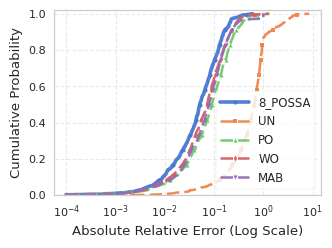

  COUNT - ARE Metrics [Budget = 10%]
          Mean  Median    P50    P75     P90     P95     Max
method                                                      
8_POSSA  7.47%   5.12%  5.12% 10.39%  15.70%  20.85%  60.36%
UN      79.00%  65.71% 65.71% 88.31% 129.05% 257.43% 849.81%
PO      12.62%   9.07%  9.07% 17.28%  26.39%  37.80% 132.62%
WO      10.02%   7.22%  7.22% 13.26%  21.68%  28.38% 130.52%
MAB     12.05%   7.83%  7.83% 13.98%  21.99%  29.88% 100.00%



In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 用户配置
# ==========================================
dataset_name = 'dataset_three'
AGG_TYPE = 'count'   # 未被用作文件名后缀，本脚本使用固定 ablation 文件
main_dataset = 'parler'
main_predicate_obj = 'post'

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"
path_alloc_ablation = os.path.join(base_dir, "allocation_strategy_comparison_ablation.csv")

out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)

PLOTTING_BUDGETS = [0.05, 0.1]        # 根据需要修改
ERROR_METRIC = 'ARE'                  # 'ARE' 或 'SymRE'
X_AXIS_SCALE = 'log'                  # 'log' or 'linear'
EPS = 1e-9

# 比较方法顺序（严格只比较这些）
COMPARE_METHODS = ["8_POSSA", "UN", "PO", "WO", "MAB"]

# ==========================================
# 全局绘图风格（VLDB 友好）
# ==========================================
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('seaborn-whitegrid')

plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 9,
    'axes.labelsize': 9.5,
    'legend.fontsize': 8.5,
    'xtick.labelsize': 8.0,
    'ytick.labelsize': 8.0,
    'axes.linewidth': 0.9,
})

# 颜色与线型（柔和 + 区分主方法）
palette = sns.color_palette("muted", n_colors=len(COMPARE_METHODS))
COLOR_MAP = dict(zip(COMPARE_METHODS, palette))
LINESTYLE = {m: ('-' if m == "8_POSSA" else (0, (5, 2))) for m in COMPARE_METHODS}
LINEWIDTH = {m: (2.6 if m == "8_POSSA" else 1.8) for m in COMPARE_METHODS}
MARKER = {"8_POSSA": "o", "UN": "s", "PO": "^", "WO": "d", "MAB": "v"}

# ==========================================
# 数据加载
# ==========================================
if not os.path.exists(path_alloc_ablation):
    raise FileNotFoundError(f"缺少文件: {path_alloc_ablation}")

df = pd.read_csv(path_alloc_ablation, dtype={"query_basename": str})
if "query_basename" in df.columns:
    df["query_basename"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)

# 确保包含必要列
required_cols = {"query_basename", "method", "budget_frac", "T_hat", "T_true"}
miss = required_cols - set(df.columns)
if miss:
    raise ValueError(f"输入 CSV 缺少列: {miss}，请确认 {path_alloc_ablation}")

# 只保留比较方法
df = df[df["method"].isin(COMPARE_METHODS)].copy()
if df.empty:
    raise ValueError("在文件中没有发现要比较的方法，请检查 method 名称是否匹配。")

# 过滤掉没有有效 T_true 的记录
df = df.dropna(subset=["T_true"])
df = df[df["T_true"] != 0].copy()

# 计算误差列
df["ARE"] = (df["T_hat"] - df["T_true"]).abs() / (df["T_true"] + EPS)
df["SymRE"] = (df["T_hat"] - df["T_true"]).abs() / (0.5 * (df["T_hat"] + df["T_true"]) + EPS)
error_col = ERROR_METRIC
if X_AXIS_SCALE == "log":
    df["PlotValue"] = np.maximum(df[error_col], 1e-4)
else:
    df["PlotValue"] = df[error_col]

# ==========================================
# 绘图：按 budget 绘制 CDF
# ==========================================
for budget in PLOTTING_BUDGETS:
    mask = df["budget_frac"].apply(lambda x: np.isclose(x, budget, atol=1e-4))
    subset = df[mask].copy()
    if subset.empty:
        print(f"[Skip] budget={budget:.3f} 无数据，跳过")
        continue

    # 确定当前方法顺序（保持 COMPARE_METHODS 的顺序）
    current_methods = [m for m in COMPARE_METHODS if m in subset["method"].unique()]
    if not current_methods:
        print(f"[Skip] budget={budget:.3f} 未找到匹配方法，跳过")
        continue

    fig, ax = plt.subplots(figsize=(3.4, 2.55))  # 单栏友好尺寸

    for method in current_methods:
        vals = subset[subset["method"] == method]["PlotValue"].dropna().sort_values().values
        if vals.size == 0:
            continue
        y = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, y,
                label=method,
                color=COLOR_MAP.get(method, "gray"),
                linestyle=LINESTYLE.get(method, "--"),
                linewidth=LINEWIDTH.get(method, 1.6),
                marker=MARKER.get(method, None),
                markersize=3.0,
                markevery=max(1, len(vals)//12),
                alpha=0.95)

    # 装饰
    ax.set_xlabel(f"{'Absolute Relative Error' if ERROR_METRIC=='ARE' else 'Symmetric Relative Error'}" +
                  (" (Log Scale)" if X_AXIS_SCALE == "log" else " (Linear Scale)"))
    ax.set_ylabel("Cumulative Probability")
    ax.set_ylim(0, 1.02)
    if X_AXIS_SCALE == "log":
        ax.set_xscale("log")
    else:
        ax.set_xlim(0, X_AXIS_SCALE if isinstance(X_AXIS_SCALE, (int, float)) else None)

    ax.grid(True, which="major", linestyle="--", alpha=0.4)
    ax.legend(loc="lower right", frameon=True, edgecolor="#D0D5DD", fancybox=False, handlelength=2.4)

    fig.tight_layout()
    out_pdf = os.path.join(out_dir, f"cdf_{main_dataset}_{main_predicate_obj}_budget_{int(budget*100)}.pdf")
    fig.savefig(out_pdf, dpi=300, format="pdf", bbox_inches="tight")
    print(f"[+] 已保存: {out_pdf}")
    plt.show()
    plt.close(fig)

    # 统计表（Mean/Median/P50/P75/P90/P95/Max）
    percentiles = [0.5, 0.75, 0.9, 0.95]
    agg_funcs = {'Mean': 'mean', 'Median': 'median', 'Max': 'max'}
    for p in percentiles:
        agg_funcs[f"P{int(p*100)}"] = (lambda q: (lambda x: x.quantile(q)))(p)

    summary = subset.groupby("method")[error_col].agg(**agg_funcs)
    summary = summary.loc[[m for m in current_methods if m in summary.index]]
    col_order = ['Mean', 'Median'] + [f"P{int(p*100)}" for p in percentiles] + ['Max']
    summary_percent = summary[col_order] * 100

    print("="*80)
    print(f"  {AGG_TYPE.upper()} - {ERROR_METRIC} Metrics [Budget = {int(budget*100)}%]")
    print("="*80)
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.2f}%'.format):
        print(summary_percent)
    print("="*80 + "\n")

RQ4- 消融实验柱状图

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径
# ==========================================
TARGET_BUDGET = 0.1  # 消融实验通常在固定预算下进行（例如 10%）
CSV_NAME = "allocation_strategy_comparison_ablation_sum.csv"
agg_mode ='count'
# 数据集配置：路径、真值文件名、以及图表上展示的美化名称
DATASETS_CONFIG = {
    "Parler": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Parler-E": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Amazon-E": {
        "base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results",
        "json_name": f"T_true_ML3_oracle1_probability_ML2_oracle1_probability_{agg_mode}.json"
    }
}

# 内部方法名到展示名的映射（如果你的 CSV 里名字不同，请修改左侧的 Key）
# 假设 POSS 在 CSV 里叫 "8_POSSA" 或 "POSS"
METHOD_MAP = {
    "UN": "UN",
    "PO": "PO",
    "WO": "WO",
    "MAB": "MAB",
    "8_POSSA": "POSS",  
    "POSS": "POSS"
}

# 图表上柱子的排列顺序（最基础的放左边，最好的放最右边）
DISPLAY_ORDER = ["UN", "PO", "WO", "MAB", "POSS"]

# 输出路径
out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "ablation_grouped_bar_vldb.pdf")

# ==========================================
# 2. VLDB 绘图规范初始化
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,
})

# ==========================================
# 3. 数据加载与处理函数
# ==========================================
def load_ablation_data():
    all_records = []
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        eff_dir = os.path.join(base_dir, "efficiency")
        
        csv_path = os.path.join(eff_dir, CSV_NAME)
        json_path = os.path.join(base_dir, config["json_name"])
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            print(f"[Warn] 缺失文件，跳过 {display_name}...")
            continue
            
        # 1. 加载真值 JSON
        with open(json_path, 'r') as f:
            t_true_dict = json.load(f)
        # 清理 JSON Key 中的 .graph
        t_true_map = {k.replace(".graph", ""): float(v) for k, v in t_true_dict.items()}
        
        # 2. 加载预测值 CSV
        df = pd.read_csv(csv_path)
        
        # 过滤目标预算
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        # 映射方法名
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) # 忽略不在 MAP 里的方法
        
        # 匹配真值
        df["query_clean"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        df["T_true"] = df["query_clean"].map(t_true_map)
        
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        # 计算 ARE
        eps = 1e-9
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + eps)
        
        # 计算每个方法的 AAE (Mean ARE)
        grouped = df.groupby("method_display")["ARE"].mean().reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name,
                "Method": row["method_display"],
                "AAE": row["ARE"] * 100  # 转换为百分比，方便阅读
            })
            
    return pd.DataFrame(all_records)

# ==========================================
# 4. 执行加载并准备画图
# ==========================================
print("[*] 正在跨数据集加载消融实验数据...")
df_plot = load_ablation_data()

if df_plot.empty:
    raise RuntimeError("没有加载到任何有效数据，请检查路径和列名！")

# 强制转换方法列为类别，以保证绘图顺序
df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
df_plot = df_plot.sort_values(["Dataset", "Method"])

# 在控制台打印 LaTeX 写表格用的原始数据
print("\n" + "="*60)
print(f"   Ablation Results - AAE (%) at Budget = {TARGET_BUDGET*100:.0f}%")
print("="*60)
pivot_df = df_plot.pivot(index="Method", columns="Dataset", values="AAE")
print(pivot_df.to_string(float_format="{:.2f}%".format))
print("="*60 + "\n")

# ==========================================
# 5. 绘制分组柱状图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 4.2))

# 使用学术风格配色 (可以改成 "muted" 或 "Paired")
palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

# 核心画图命令
sns.barplot(
    data=df_plot, 
    x="Dataset", 
    y="AAE", 
    hue="Method", 
    palette=palette,
    edgecolor="black",  # 加上黑色描边，顶会质感瞬间拉满
    linewidth=0.8,
    ax=ax
)

# 【关键设置】开启 Y 轴对数缩放
ax.set_yscale("log")
ax.set_ylabel("Mean Absolute Relative Error (%)", fontweight="bold")
ax.set_xlabel("")  # X轴本身已经是数据集名字了，不需要额外标签

# 设置 Y 轴标签格式化（显示数字而不是 10^x）
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}%'.format(y)))

# 添加背景网格线，辅助对齐
ax.grid(axis='y', which='major', linestyle='-', alpha=0.3, color='gray')
ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, color='gray')

# 【高阶技巧】在每个柱子顶部标注精确数值
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.isna(height) or height <= 0:
            continue
        
        # 针对 Log 轴：文本的 Y 坐标用乘法略微抬高 (1.15倍)，避免贴得太紧
        ax.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=7.5,
            fontweight='bold',
            color='black',
            rotation=0
        )

# 调整图例位置，放外面或者顶层，不遮挡数据
ax.legend(
    title="Allocation Strategy", 
    title_fontsize=9,
    fontsize=9,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(DISPLAY_ORDER), 
    frameon=False
)

# 紧凑布局并保存
fig.tight_layout()
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"✅ VLDB 级分组柱状图已生成: {out_pdf}")

plt.show()
plt.close(fig)

[*] 正在跨数据集加载消融实验数据...


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

最终消融实验柱状图

[*] 正在跨数据集加载消融实验数据...
✅ VLDB 级分组柱状图 (linear 坐标系, 含 Median 红点) 已生成: /home/wangshuo/resource/paper_figuires/ablation_grouped_bar_vldb_linear.pdf


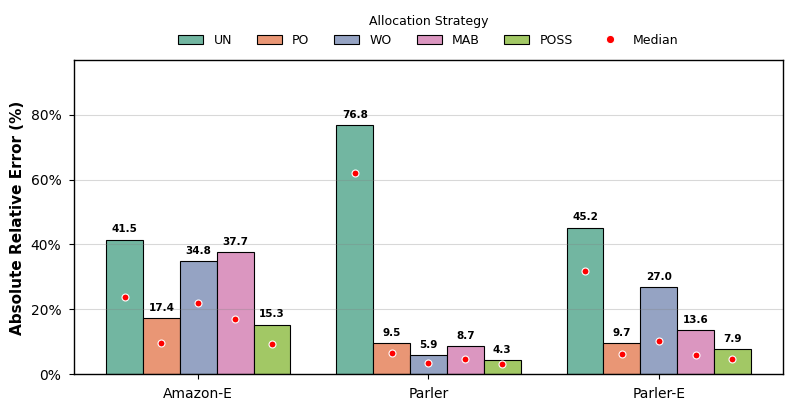

In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  # 用于自定义图例
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
agg_mode ='sum'
CSV_NAME = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"

# 坐标轴控制：可选 "log" 或 "linear"
Y_SCALE = "linear"  

# 数据集配置
DATASETS_CONFIG = {
    "Parler": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Parler-E": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Amazon-E": {
        "base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results",
        "json_name": f"T_true_ML3_oracle1_probability_ML2_oracle1_probability_{agg_mode}.json"
        # "json_name": f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
    }
}

METHOD_MAP = {
    "UN": "UN",
    "PO": "PO",
    "WO": "WO",
    "MAB": "MAB",
    "8_POSSA": "POSS",  
    "POSS": "POSS"
}

DISPLAY_ORDER = ["UN", "PO", "WO", "MAB", "POSS"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"ablation_grouped_bar_vldb_{Y_SCALE}.pdf")

# ==========================================
# 2. VLDB 绘图规范初始化
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,
})

# ==========================================
# 3. 数据加载与处理函数
# ==========================================
def load_ablation_data():
    all_records = []
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        eff_dir = os.path.join(base_dir, "efficiency")
        
        csv_path = os.path.join(eff_dir, CSV_NAME)
        json_path = os.path.join(base_dir, config["json_name"])
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            print(f"[Warn] 缺失文件，跳过 {display_name}...")
            continue
            
        with open(json_path, 'r') as f:
            t_true_dict = json.load(f)
        t_true_map = {k.replace(".graph", ""): float(v) for k, v in t_true_dict.items()}
        
        df = pd.read_csv(csv_path)
        
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        
        df["query_clean"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        df["T_true"] = df["query_clean"].map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        eps = 1e-9
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + eps)
        
        # 【修改点 1】同时计算 Mean 和 Median
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name,
                "Method": row["method_display"],
                "AAE": row["mean"] * 100,         # 柱子的高度（均值）
                "Median_AAE": row["median"] * 100 # 红点的高度（中位数）
            })
            
    return pd.DataFrame(all_records)

# ==========================================
# 4. 执行加载并准备画图
# ==========================================
print("[*] 正在跨数据集加载消融实验数据...")
df_plot = load_ablation_data()

if df_plot.empty:
    raise RuntimeError("没有加载到任何有效数据，请检查路径和列名！")

df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
df_plot = df_plot.sort_values(["Dataset", "Method"])

# ==========================================
# 5. 绘制分组柱状图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 4.2))
palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

sns.barplot(
    data=df_plot, 
    x="Dataset", 
    y="AAE", 
    hue="Method", 
    palette=palette,
    edgecolor="black",  
    linewidth=0.8,
    ax=ax
)

ax.set_yscale(Y_SCALE)
ax.set_ylabel("Absolute Relative Error (%)", fontweight="bold")
ax.set_xlabel("")  
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}%'.format(y)))

if Y_SCALE == "log":
    ax.grid(axis='y', which='major', linestyle='-', alpha=0.3, color='gray')
    ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, color='gray')
else:
    ax.grid(axis='y', which='major', linestyle='-', alpha=0.3, color='gray')
    ymin, ymax = ax.get_ylim()
    # 稍微多留一点顶部空间，防止均值和中位数重合时文字越界
    ax.set_ylim(ymin, ymax * 1.20) 

# 获取数据集中 Dataset 的唯一值（保持与图表X轴刻度顺序一致）
datasets_order = df_plot["Dataset"].unique()

# 在每个柱子中心画红点 (Median)，并在顶部标数字 (Mean)
# ax.containers 中的顺序与 DISPLAY_ORDER 完全一致 (因为做了 pd.Categorical)
for i, container in enumerate(ax.containers):
    method_name = DISPLAY_ORDER[i]
    
    for j, bar in enumerate(container):
        height = bar.get_height()  # 均值
        if pd.isna(height) or height <= 0:
            continue
            
        # 计算当前柱子的 X 轴中心坐标
        x_pos = bar.get_x() + bar.get_width() / 2
        dataset_name = datasets_order[j]
        
        # 从 DataFrame 中取出对应的中位数
        median_val = df_plot[
            (df_plot["Method"] == method_name) & 
            (df_plot["Dataset"] == dataset_name)
        ]["Median_AAE"].values[0]

        # 画红点：添加白边(markeredgecolor='white')防止与柱子颜色混在一起
        ax.plot(x_pos, median_val, marker='o', color='red', 
                markersize=5, zorder=3, markeredgecolor='white', markeredgewidth=0.8)
        
        # 原有的均值文字标注
        ax.annotate(
            f'{height:.1f}',
            xy=(x_pos, height),
            xytext=(0, 4),  # 向上偏移4个像素
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=7.5,
            fontweight='bold',
            color='black',
            rotation=0
        )

# 为图例增加 "Median" 标识
handles, labels = ax.get_legend_handles_labels()
# 手动创建一个红点的图例句柄
median_marker = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                              markersize=6, markeredgecolor='white', markeredgewidth=0.8, 
                              label='Median')
handles.append(median_marker)
labels.append('Median')

# 重新生成图例
ax.legend(
    handles=handles,
    labels=labels,
    title="Allocation Strategy", 
    title_fontsize=9,
    fontsize=9,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.18),  # 稍微向上抬一点，为新增的图例留出空间
    ncol=len(DISPLAY_ORDER) + 1, # 增加一列放 Median
    frameon=False
)

fig.tight_layout()
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"✅ VLDB 级分组柱状图 ({Y_SCALE} 坐标系, 含 Median 红点) 已生成: {out_pdf}")

plt.show()
plt.close(fig)

图 + 文本信息

[*] 正在跨数据集加载消融实验数据...

                  ABLATION STUDY METRIC SUMMARY (Target Budget = 10%, Mode = COUNT)
Method                  UN     PO     WO    MAB   POSS
Dataset  Metric                                       
Parler   Mean ARE   42.29%  9.06% 22.88% 10.41%  4.95%
         Median ARE 34.54%  5.78% 18.16%  6.29%  3.68%
Parler-E Mean ARE   25.91%  7.25% 22.22%  8.97%  5.44%
         Median ARE 14.66%  4.00% 11.88%  3.72%  2.60%
Amazon-E Mean ARE   24.64% 20.16% 21.14% 30.68% 12.00%
         Median ARE 11.71%  9.75%  9.99% 17.71%  6.98%

✅ VLDB 级分组柱状图 (linear 坐标系, 含 Median 红点) 已生成: /home/wangshuo/resource/paper_figuires/ablation_grouped_bar_vldb_linear.pdf


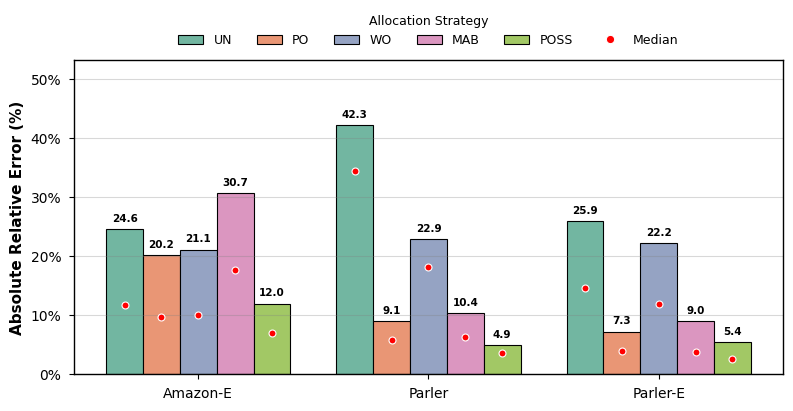

In [13]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  # 用于自定义图例
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
agg_mode ='count'
CSV_NAME = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"

# 坐标轴控制：可选 "log" 或 "linear"
Y_SCALE = "linear"  

# 数据集配置
DATASETS_CONFIG = {
    "Parler": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Parler-E": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Amazon-E": {
        "base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results",
        # "json_name": f"T_true_ML3_oracle1_probability_ML2_oracle1_probability_{agg_mode}.json"
        "json_name": f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
    }
}

METHOD_MAP = {
    "UN": "UN",
    "PO": "PO",
    "WO": "WO",
    "MAB": "MAB",
    "8_POSSA": "POSS",  
    "POSS": "POSS"
}

DISPLAY_ORDER = ["UN", "PO", "WO", "MAB", "POSS"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"ablation_grouped_bar_vldb_{Y_SCALE}.pdf")

# ==========================================
# 2. VLDB 绘图规范初始化
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,
})

# ==========================================
# 3. 数据加载与处理函数
# ==========================================
def load_ablation_data():
    all_records = []
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        eff_dir = os.path.join(base_dir, "efficiency")
        
        csv_path = os.path.join(eff_dir, CSV_NAME)
        json_path = os.path.join(base_dir, config["json_name"])
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            print(f"[Warn] 缺失文件，跳过 {display_name}...")
            continue
            
        with open(json_path, 'r') as f:
            t_true_dict = json.load(f)
        t_true_map = {k.replace(".graph", ""): float(v) for k, v in t_true_dict.items()}
        
        df = pd.read_csv(csv_path)
        
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        
        df["query_clean"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        df["T_true"] = df["query_clean"].map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        eps = 1e-9
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + eps)
        
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name,
                "Method": row["method_display"],
                "AAE": row["mean"] * 100,         # 柱子的高度（均值）
                "Median_AAE": row["median"] * 100 # 红点的高度（中位数）
            })
            
    return pd.DataFrame(all_records)

# ==========================================
# 4. 执行加载并准备画图
# ==========================================
print("[*] 正在跨数据集加载消融实验数据...")
df_plot = load_ablation_data()

if df_plot.empty:
    raise RuntimeError("没有加载到任何有效数据，请检查路径和列名！")

df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
df_plot = df_plot.sort_values(["Dataset", "Method"])

# ==========================================
# 【新增：控制台学术汇总表输出】
# ==========================================
print("\n" + "="*90)
print(" " * 18 + f"ABLATION STUDY METRIC SUMMARY (Target Budget = {TARGET_BUDGET*100:.0f}%, Mode = {agg_mode.upper()})")
print("="*90)

# 对数据进行重塑以便以标准学术多重索引表格打印
df_melted = df_plot.melt(
    id_vars=["Dataset", "Method"], 
    value_vars=["AAE", "Median_AAE"], 
    var_name="Metric", 
    value_name="Value"
)
df_melted["Metric"] = df_melted["Metric"].map({"AAE": "Mean ARE", "Median_AAE": "Median ARE"})

# 设定 categorical 排序保证打印顺序稳定一致
df_melted["Dataset"] = pd.Categorical(df_melted["Dataset"], categories=list(DATASETS_CONFIG.keys()), ordered=True)
df_melted["Method"] = pd.Categorical(df_melted["Method"], categories=DISPLAY_ORDER, ordered=True)

pivot_table = df_melted.pivot_table(
    index=["Dataset", "Metric"], 
    columns="Method", 
    values="Value", 
    sort=False
)

# 确保列序符合 DISPLAY_ORDER
pivot_table = pivot_table[DISPLAY_ORDER]

# 在控制台优雅地排版输出百分比数据
with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.2f}%'.format):
    print(pivot_table)
print("="*90 + "\n")

# ==========================================
# 5. 绘制分组柱状图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 4.2))
palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

sns.barplot(
    data=df_plot, 
    x="Dataset", 
    y="AAE", 
    hue="Method", 
    palette=palette,
    edgecolor="black",  
    linewidth=0.8,
    ax=ax
)

ax.set_yscale(Y_SCALE)
ax.set_ylabel("Absolute Relative Error (%)", fontweight="bold")
ax.set_xlabel("")  
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}%'.format(y)))

if Y_SCALE == "log":
    ax.grid(axis='y', which='major', linestyle='-', alpha=0.3, color='gray')
    ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, color='gray')
else:
    ax.grid(axis='y', which='major', linestyle='-', alpha=0.3, color='gray')
    ymin, ymax = ax.get_ylim()
    # 稍微多留一点顶部空间，防止均值和中位数重合时文字越界
    ax.set_ylim(ymin, ymax * 1.20) 

# 获取数据集中 Dataset 的唯一值（保持与图表X轴刻度顺序一致）
datasets_order = df_plot["Dataset"].unique()

# 在每个柱子中心画红点 (Median)，并在顶部标数字 (Mean)
for i, container in enumerate(ax.containers):
    method_name = DISPLAY_ORDER[i]
    
    for j, bar in enumerate(container):
        height = bar.get_height()  # 均值
        if pd.isna(height) or height <= 0:
            continue
            
        # 计算当前柱子的 X 轴中心坐标
        x_pos = bar.get_x() + bar.get_width() / 2
        dataset_name = datasets_order[j]
        
        # 从 DataFrame 中取出对应的中位数
        median_val = df_plot[
            (df_plot["Method"] == method_name) & 
            (df_plot["Dataset"] == dataset_name)
        ]["Median_AAE"].values[0]

        # 画红点：添加白边防止与柱子颜色混在一起
        ax.plot(x_pos, median_val, marker='o', color='red', 
                markersize=5, zorder=3, markeredgecolor='white', markeredgewidth=0.8)
        
        # 原有的均值文字标注
        ax.annotate(
            f'{height:.1f}',
            xy=(x_pos, height),
            xytext=(0, 4),  # 向上偏移4个像素
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=7.5,
            fontweight='bold',
            color='black',
            rotation=0
        )

# 为图例增加 "Median" 标识
handles, labels = ax.get_legend_handles_labels()
# 手动创建一个红点的图例句柄
median_marker = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                              markersize=6, markeredgecolor='white', markeredgewidth=0.8, 
                              label='Median')
handles.append(median_marker)
labels.append('Median')

# 重新生成图例
ax.legend(
    handles=handles,
    labels=labels,
    title="Allocation Strategy", 
    title_fontsize=9,
    fontsize=9,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.18),  # 稍微向上抬一点，为新增的图例留出空间
    ncol=len(DISPLAY_ORDER) + 1, # 增加一列放 Median
    frameon=False
)

fig.tight_layout()
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"✅ VLDB 级分组柱状图 ({Y_SCALE} 坐标系, 含 Median 红点) 已生成: {out_pdf}")

plt.show()
plt.close(fig)

[*] 正在跨数据集加载消融实验数据...

                  ABLATION STUDY METRIC SUMMARY (Target Budget = 10%, Mode = SUM)
Method                  UN     PO     WO    MAB  POSS
Dataset  Metric                                      
Parler   Mean ARE   76.85%  9.52%  5.90%  8.74% 4.34%
         Median ARE 61.96%  6.68%  3.52%  4.83% 3.11%
Parler-E Mean ARE   45.22%  9.65% 27.01% 13.62% 7.86%
         Median ARE 31.89%  6.18% 10.14%  5.89% 4.74%
Amazon-E Mean ARE   31.84% 14.51% 27.78% 20.52% 9.31%
         Median ARE 16.31%  8.12% 12.92%  8.75% 5.50%

✅ 完美单栏 PDF 已生成至: /home/wangshuo/resource/paper_figuires/ablation_grouped_bar_sum_vldb_linear.pdf


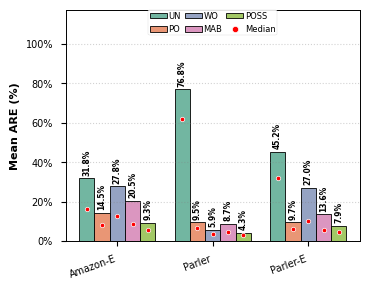

In [2]:
import os
import json
import re
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  # 用于自定义图例
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
# 🚨 运行第二次时，请将这里修改为 'sum'
agg_mode ='sum'
CSV_NAME = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"

# 坐标轴控制：可选 "log" 或 "linear"
Y_SCALE = "linear"  

# 数据集配置
DATASETS_CONFIG = {
    "Parler": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Parler-E": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Amazon-E": {
        "base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results",
        "json_name": f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
    }
}

METHOD_MAP = {
    "UN": "UN",
    "PO": "PO",
    "WO": "WO",
    "MAB": "MAB",
    "8_POSSA": "POSS",  
    "POSS": "POSS"
}

DISPLAY_ORDER = ["UN", "PO", "WO", "MAB", "POSS"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)

# 🚨 【核心修改】：输出文件名融入 agg_mode 变量，防止运行第二次时将第一次的结果覆盖！
out_pdf = os.path.join(out_dir, f"ablation_grouped_bar_{agg_mode}_vldb_{Y_SCALE}.pdf")

# ==========================================
# 2. IEEE / ICDE 极致紧凑双栏排版规范
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,   # TrueType 嵌入（顶会硬性指标）
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 7.5,
    "axes.labelsize": 8.0,
    "axes.titlesize": 8.5,
    "legend.fontsize": 6.0,  # 紧凑图例字号
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "axes.linewidth": 0.7,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.2
})

# ==========================================
# 3. 数据加载与处理函数
# ==========================================
def load_ablation_data():
    all_records = []
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        eff_dir = os.path.join(base_dir, "efficiency")
        
        csv_path = os.path.join(eff_dir, CSV_NAME)
        json_path = os.path.join(base_dir, config["json_name"])
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            print(f"[Warn] 缺失文件，跳过 {display_name}...")
            continue
            
        with open(json_path, 'r') as f:
            t_true_dict = json.load(f)
        t_true_map = {k.replace(".graph", ""): float(v) for k, v in t_true_dict.items()}
        
        df = pd.read_csv(csv_path)
        
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        
        df["query_clean"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        df["T_true"] = df["query_clean"].map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        eps = 1e-9
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + eps)
        
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name,
                "Method": row["method_display"],
                "AAE": row["mean"] * 100,         # 柱子的高度（均值）
                "Median_AAE": row["median"] * 100 # 红点的高度（中位数）
            })
            
    return pd.DataFrame(all_records)

# ==========================================
# 4. 执行加载并准备画图
# ==========================================
print("[*] 正在跨数据集加载消融实验数据...")
df_plot = load_ablation_data()

if df_plot.empty:
    raise RuntimeError("没有加载到任何有效数据，请检查路径和列名！")

df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
df_plot = df_plot.sort_values(["Dataset", "Method"])

# ==========================================
# 控制台学术汇总表输出
# ==========================================
print("\n" + "="*90)
print(" " * 18 + f"ABLATION STUDY METRIC SUMMARY (Target Budget = {TARGET_BUDGET*100:.0f}%, Mode = {agg_mode.upper()})")
print("="*90)

df_melted = df_plot.melt(
    id_vars=["Dataset", "Method"], 
    value_vars=["AAE", "Median_AAE"], 
    var_name="Metric", 
    value_name="Value"
)
df_melted["Metric"] = df_melted["Metric"].map({"AAE": "Mean ARE", "Median_AAE": "Median ARE"})
df_melted["Dataset"] = pd.Categorical(df_melted["Dataset"], categories=list(DATASETS_CONFIG.keys()), ordered=True)
df_melted["Method"] = pd.Categorical(df_melted["Method"], categories=DISPLAY_ORDER, ordered=True)

pivot_table = df_melted.pivot_table(
    index=["Dataset", "Metric"], 
    columns="Method", 
    values="Value", 
    sort=False
)
pivot_table = pivot_table[DISPLAY_ORDER]

with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.2f}%'.format):
    print(pivot_table)
print("="*90 + "\n")

# ==========================================
# 5. 绘制分组柱状图 (🚨 IEEE单栏 3.5 英寸物理尺寸设计)
# ==========================================
fig, ax = plt.subplots(figsize=(3.5, 2.7)) # 🚨 IEEE 单栏标准物理尺寸
palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

sns.barplot(
    data=df_plot, 
    x="Dataset", 
    y="AAE", 
    hue="Method", 
    hue_order=DISPLAY_ORDER, # 🚨 极其关键：显式指定对齐顺序，确保容器索引绝对不会和红点错位！
    palette=palette,
    edgecolor="black",  
    linewidth=0.6,
    ax=ax
)

ax.set_yscale(Y_SCALE)
ax.set_ylabel("Mean ARE (%)", fontweight="bold") # 🚨 学术化简写
ax.set_xlabel("")  
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

ax.grid(axis='y', which='major', linestyle=':', alpha=0.35, color='gray')
if Y_SCALE == "log":
    ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, color='gray')
else:
    ymin, ymax = ax.get_ylim()
    # 🚨 提纯纵轴上限至 1.45 倍，为上方的紧凑图例留出物理通道，绝对防遮挡
    ax.set_ylim(0, ymax * 1.45) 

# 获取数据集中 Dataset 的唯一值
datasets_order = df_plot["Dataset"].unique()

# 在每个柱子中心画红点 (Median)，并在顶部标数字 (Mean)
for i, container in enumerate(ax.containers):
    method_name = DISPLAY_ORDER[i]
    
    for j, bar in enumerate(container):
        height = bar.get_height()  # 均值
        if pd.isna(height) or height <= 0:
            continue
            
        # 计算当前柱子的 X 轴中心坐标
        x_pos = bar.get_x() + bar.get_width() / 2
        dataset_name = datasets_order[j]
        
        # 从 DataFrame 中取出对应的中位数
        median_val = df_plot[
            (df_plot["Method"] == method_name) & 
            (df_plot["Dataset"] == dataset_name)
        ]["Median_AAE"].values[0]

        # 🚨 缩放红点尺寸至 3.5 适应单栏，白边描边保证对比度
        ax.plot(x_pos, median_val, marker='o', color='red', 
                markersize=3.2, zorder=3, markeredgecolor='white', markeredgewidth=0.5)
        
        # 🚨 【核心修复】：垂直旋转 90 度标注数值。这样 15 个数值横向排列时，绝对不会发生碰撞或重叠！
        ax.annotate(
            f'{height:.1f}%',
            xy=(x_pos, height),
            xytext=(0, 2),  # 向上偏移 2 个像素
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=5.5,
            fontweight='bold',
            color='black',
            rotation=90 # 垂直旋转
        )

# 为图例增加 "Median" 标识
handles, labels = ax.get_legend_handles_labels()
median_marker = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                              markersize=4.5, markeredgecolor='white', markeredgewidth=0.5, 
                              label='Median')
handles.append(median_marker)
labels.append('Median')

# 🚨 精细排列的 3 列图例，通过 bbox_to_anchor 贴附在绘图区域最上方 (移除 set_title)
ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.02),  
    ncol=3, # 🚨 改为极速紧凑的 3 列，防止大片文本挤在一行发生溢出
    framealpha=0.9,
    borderpad=0.2,
    handletextpad=0.2,
    columnspacing=0.5
)

# 🚨 倾斜 X 轴标签 20 度，防止 Amazon-E 这样的名称发生挤压
ax.tick_params(axis='x', rotation=20)
for label in ax.get_xticklabels():
     label.set_ha('right')

fig.tight_layout(pad=0.01) # 🚨 极致剥离无用边距
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"✅ 完美单栏 PDF 已生成至: {out_pdf}")

plt.show()
plt.close(fig)

[*] 正在跨数据集加载消融实验数据...
✅ 完美单栏 PDF 已生成至: /home/wangshuo/resource/paper_figuires/RQ4_ablation_grouped_bar_count.pdf


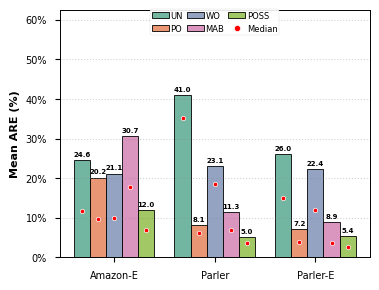

In [10]:
import os
import json
import re
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  # 用于自定义图例
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
agg_mode ='count'
CSV_NAME = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"

Y_SCALE = "linear"  

# 🚨 【用户控制区】：自由调节柱子顶部文字的显示效果
BAR_TEXT_FONTSIZE = 5.0      # 字号控制 (默认 5.0, 如果依然重叠可调小至 4.5)
REMOVE_PERCENT_SIGN = True   # 是否去掉 % 号 (强烈建议 True，可大幅减少横向宽度)

DATASETS_CONFIG = {
    "Parler": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Parler-E": {
        "base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results",
        "json_name": f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
    },
    "Amazon-E": {
        "base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results",
        "json_name": f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
    }
}

METHOD_MAP = {
    "UN": "UN",
    "PO": "PO",
    "WO": "WO",
    "MAB": "MAB",
    "8_POSSA": "POSS",  
    "POSS": "POSS"
}

DISPLAY_ORDER = ["UN", "PO", "WO", "MAB", "POSS"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)

out_pdf = os.path.join(out_dir, f"RQ4_ablation_grouped_bar_{agg_mode}.pdf")

# ==========================================
# 2. IEEE / ICDE 极致紧凑双栏排版规范
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 7.5,
    "axes.labelsize": 8.0,
    "axes.titlesize": 8.5,
    "legend.fontsize": 6.0,  
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "axes.linewidth": 0.7,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.2
})

# ==========================================
# 3. 数据加载与处理函数
# ==========================================
def load_ablation_data():
    all_records = []
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        eff_dir = os.path.join(base_dir, "efficiency")
        
        csv_path = os.path.join(eff_dir, CSV_NAME)
        json_path = os.path.join(base_dir, config["json_name"])
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            print(f"[Warn] 缺失文件，跳过 {display_name}...")
            continue
            
        with open(json_path, 'r') as f:
            t_true_dict = json.load(f)
        t_true_map = {k.replace(".graph", ""): float(v) for k, v in t_true_dict.items()}
        
        df = pd.read_csv(csv_path)
        
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        
        df["query_clean"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
        df["T_true"] = df["query_clean"].map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        eps = 1e-9
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + eps)
        
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name,
                "Method": row["method_display"],
                "AAE": row["mean"] * 100,
                "Median_AAE": row["median"] * 100 
            })
            
    return pd.DataFrame(all_records)

print("[*] 正在跨数据集加载消融实验数据...")
df_plot = load_ablation_data()

if df_plot.empty:
    raise RuntimeError("没有加载到任何有效数据，请检查路径和列名！")

df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
df_plot = df_plot.sort_values(["Dataset", "Method"])

# ==========================================
# 5. 绘制分组柱状图
# ==========================================
# 🚨 略微加宽物理尺寸 (从 3.5 增加到 3.6)，给横向的文字提供微小的物理空间裕度
fig, ax = plt.subplots(figsize=(3.6, 2.7)) 
palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

sns.barplot(
    data=df_plot, 
    x="Dataset", 
    y="AAE", 
    hue="Method", 
    hue_order=DISPLAY_ORDER, 
    palette=palette,
    edgecolor="black",  
    linewidth=0.6,
    ax=ax
)

ax.set_yscale(Y_SCALE)
ax.set_ylabel("Mean ARE (%)", fontweight="bold") 
ax.set_xlabel("")  
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

ax.grid(axis='y', which='major', linestyle=':', alpha=0.35, color='gray')
if Y_SCALE == "log":
    ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, color='gray')
else:
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.45) 

datasets_order = df_plot["Dataset"].unique()

for i, container in enumerate(ax.containers):
    method_name = DISPLAY_ORDER[i]
    for j, bar in enumerate(container):
        height = bar.get_height()
        if pd.isna(height) or height <= 0:
            continue
            
        x_pos = bar.get_x() + bar.get_width() / 2
        dataset_name = datasets_order[j]
        
        median_val = df_plot[
            (df_plot["Method"] == method_name) & 
            (df_plot["Dataset"] == dataset_name)
        ]["Median_AAE"].values[0]

        ax.plot(x_pos, median_val, marker='o', color='red', 
                markersize=3.2, zorder=3, markeredgecolor='white', markeredgewidth=0.5)
        
        # 🚨 【核心修复】：水平摆正文字，去掉%，且通过 bbox 加了一层极其微小的白色边框防止柱子颜色吃字
        text_str = f'{height:.1f}' if REMOVE_PERCENT_SIGN else f'{height:.1f}%'
        
        ax.annotate(
            text_str,
            xy=(x_pos, height),
            xytext=(0, 2),  
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=BAR_TEXT_FONTSIZE, # 🚨 由全局变量控制字号
            fontweight='bold',
            color='black',
            rotation=0, # 🚨 摆正！不旋转！
            # bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7) # (可选) 开启文字白底防止被背景干扰
        )

handles, labels = ax.get_legend_handles_labels()
median_marker = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                              markersize=4.5, markeredgecolor='white', markeredgewidth=0.5, 
                              label='Median')
handles.append(median_marker)
labels.append('Median')

ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.02),  
    ncol=3,
    framealpha=0.9,
    borderpad=0.2,
    handletextpad=0.2,
    columnspacing=0.5
)

# X 轴标签水平居中，不倾斜（如果有需要可以恢复倾斜）
ax.tick_params(axis='x', rotation=0)

fig.tight_layout(pad=0.01)
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"✅ 完美单栏 PDF 已生成至: {out_pdf}")

 代码2

✅ 极致省空间的联合 PDF 已生成: /home/wangshuo/resource/paper_figuires/ablation_combined_1x2_vldb.pdf


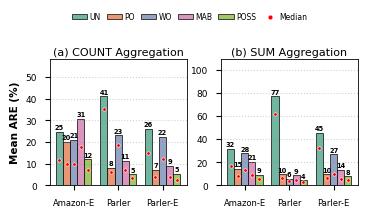

In [9]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
Y_SCALE = "linear"  

# 🚨 【核心排版控制】：为了在单栏双图中不重叠，必须采用极限排版
BAR_TEXT_FONTSIZE = 4.8      # 极限字号 (ICDE 允许的最小图表字号通常是 4.5~5pt)
ROUND_TO_INT = True          # 🚨 强烈建议设为 True：显示为 12 而不是 12.3，彻底消除重叠！

DATASETS_CONFIG = {
    "Parler": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results"},
    "Parler-E": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results"},
    "Amazon-E": {"base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results"}
}

METHOD_MAP = {"UN": "UN", "PO": "PO", "WO": "WO", "MAB": "MAB", "8_POSSA": "POSS", "POSS": "POSS"}
DISPLAY_ORDER = ["UN", "PO", "WO", "MAB", "POSS"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"ablation_combined_1x2_vldb.pdf") # 🚨 输出单一的联合 PDF

# ==========================================
# 2. IEEE / ICDE 极致紧凑双栏排版规范
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 7.0,
    "axes.labelsize": 7.5,
    "axes.titlesize": 8.0,
    "legend.fontsize": 5.5,  
    "xtick.labelsize": 6.0,   # X轴数据集名称再稍微缩小一点防止挤碰
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.6,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.0
})

# ==========================================
# 3. 数据加载函数 (动态适配 count 和 sum)
# ==========================================
def load_data_for_mode(agg_mode):
    all_records = []
    csv_name = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        json_name = f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
        
        if display_name == "Amazon-E":
            json_name = f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
            
        csv_path = os.path.join(base_dir, "efficiency", csv_name)
        json_path = os.path.join(base_dir, json_name)
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            continue
            
        with open(json_path, 'r') as f:
            t_true_map = {k.replace(".graph", ""): float(v) for k, v in json.load(f).items()}
        
        df = pd.read_csv(csv_path)
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        df["T_true"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True).map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + 1e-9)
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name, "Method": row["method_display"],
                "AAE": row["mean"] * 100, "Median_AAE": row["median"] * 100 
            })
            
    df_plot = pd.DataFrame(all_records)
    if not df_plot.empty:
        df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
        df_plot = df_plot.sort_values(["Dataset", "Method"])
    return df_plot

# ==========================================
# 4. 绘制 1x2 横向紧凑双子图
# ==========================================
# 🚨 IEEE 单栏最大宽度为 3.5 英寸。我们采用 (3.5, 1.8) 让图片极为扁平，最大化节省垂直空间！
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.8), sharey=False)
palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

modes = ['count', 'sum']
titles = ['(a) COUNT Aggregation', '(b) SUM Aggregation']

for idx, mode in enumerate(modes):
    ax = axes[idx]
    df_plot = load_data_for_mode(mode)
    
    if df_plot.empty:
        ax.set_title(f"No Data for {mode}")
        continue

    sns.barplot(
        data=df_plot, x="Dataset", y="AAE", hue="Method", hue_order=DISPLAY_ORDER, 
        palette=palette, edgecolor="black", linewidth=0.5, ax=ax
    )

    ax.set_title(titles[idx], pad=3)
    ax.set_xlabel("")  
    ax.grid(axis='y', which='major', linestyle=':', alpha=0.35, color='gray')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}')) # Y轴去掉%，只留数字
    
    if idx == 0:
        ax.set_ylabel("Mean ARE (%)", fontweight="bold") 
    else:
        ax.set_ylabel("") # 右图省去 Y 轴 Label 节省空间
        
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.35) # 给顶部留空间

    # 去掉每个子图自带的 Legend
    ax.get_legend().remove()

    datasets_order = df_plot["Dataset"].unique()
    for i, container in enumerate(ax.containers):
        method_name = DISPLAY_ORDER[i]
        for j, bar in enumerate(container):
            height = bar.get_height()
            if pd.isna(height) or height <= 0: continue
                
            x_pos = bar.get_x() + bar.get_width() / 2
            dataset_name = datasets_order[j]
            median_val = df_plot[(df_plot["Method"] == method_name) & (df_plot["Dataset"] == dataset_name)]["Median_AAE"].values[0]

            ax.plot(x_pos, median_val, marker='o', color='red', markersize=2.5, zorder=3, markeredgecolor='white', markeredgewidth=0.4)
            
            # 🚨 极限化简数值：去除小数，转化为整型
            text_str = f'{int(round(height))}' if ROUND_TO_INT else f'{height:.1f}'
            
            ax.annotate(text_str, xy=(x_pos, height), xytext=(0, 1), textcoords="offset points",
                        ha='center', va='bottom', fontsize=BAR_TEXT_FONTSIZE, fontweight='bold', color='black', rotation=0)

    ax.tick_params(axis='x', rotation=0)

# ==========================================
# 5. 生成全局图例并完美对齐
# ==========================================
handles, labels = axes[0].get_legend_handles_labels()
handles.append(mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=3.5, markeredgecolor='white', markeredgewidth=0.4))
labels.append('Median')

# 🚨 将 Legend 放在两张图的正中间顶部，分为 6 列排开，霸气且不占图内空间
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
           ncol=6, frameon=False, columnspacing=0.8, handletextpad=0.3)

# 调整子图间距
plt.subplots_adjust(wspace=0.25, top=0.85, bottom=0.15, left=0.1, right=0.98)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"✅ 极致省空间的联合 PDF 已生成: {out_pdf}")

In [ ]:
代码3

✅ 极致省空间的联合 PDF 已生成: /home/wangshuo/resource/paper_figuires/ablation_combined_1x2_vldb.pdf


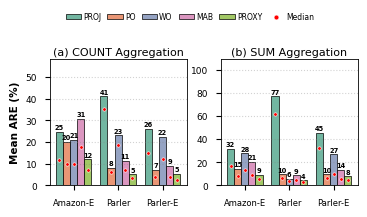

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
Y_SCALE = "linear"  

# 🚨 【核心排版控制】：为了在单栏双图中不重叠，必须采用极限排版
BAR_TEXT_FONTSIZE = 4.8      # 极限字号 (ICDE 允许的最小图表字号通常是 4.5~5pt)
ROUND_TO_INT = True          # 🚨 强烈建议设为 True：显示为 12 而不是 12.3，彻底消除重叠！

DATASETS_CONFIG = {
    "Parler": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results"},
    "Parler-E": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results"},
    "Amazon-E": {"base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results"}
}

# 🚨 已将 UN 映射为 UNI，POSS 映射为 PROJ 以避免图例及数据合并冲突
METHOD_MAP = {"UN": "PROJ", "PO": "PO", "WO": "WO", "MAB": "MAB", "8_POSSA": "PROXY", "POSS": "PROXY"}
DISPLAY_ORDER = ["PROJ", "PO", "WO", "MAB", "PROXY"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"ablation_combined_1x2_vldb.pdf") # 🚨 输出单一的联合 PDF

# ==========================================
# 2. IEEE / ICDE 极致紧凑双栏排版规范
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 7.0,
    "axes.labelsize": 7.5,
    "axes.titlesize": 8.0,
    "legend.fontsize": 5.5,  
    "xtick.labelsize": 6.0,   # X轴数据集名称再稍微缩小一点防止挤碰
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.6,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.0
})

# ==========================================
# 3. 数据加载函数 (动态适配 count 和 sum)
# ==========================================
def load_data_for_mode(agg_mode):
    all_records = []
    csv_name = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        json_name = f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
        
        if display_name == "Amazon-E":
            json_name = f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
            
        csv_path = os.path.join(base_dir, "efficiency", csv_name)
        json_path = os.path.join(base_dir, json_name)
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            continue
            
        with open(json_path, 'r') as f:
            t_true_map = {k.replace(".graph", ""): float(v) for k, v in json.load(f).items()}
        
        df = pd.read_csv(csv_path)
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        df["T_true"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True).map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + 1e-9)
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name, "Method": row["method_display"],
                "AAE": row["mean"] * 100, "Median_AAE": row["median"] * 100 
            })
            
    df_plot = pd.DataFrame(all_records)
    if not df_plot.empty:
        df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
        df_plot = df_plot.sort_values(["Dataset", "Method"])
    return df_plot

# ==========================================
# 4. 绘制 1x2 横向紧凑双子图
# ==========================================
# 🚨 IEEE 单栏最大宽度为 3.5 英寸。我们采用 (3.5, 1.8) 让图片极为扁平，最大化节省垂直空间！
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.8), sharey=False)
palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

modes = ['count', 'sum']
titles = ['(a) COUNT Aggregation', '(b) SUM Aggregation']

for idx, mode in enumerate(modes):
    ax = axes[idx]
    df_plot = load_data_for_mode(mode)
    
    if df_plot.empty:
        ax.set_title(f"No Data for {mode}")
        continue

    sns.barplot(
        data=df_plot, x="Dataset", y="AAE", hue="Method", hue_order=DISPLAY_ORDER, 
        palette=palette, edgecolor="black", linewidth=0.5, ax=ax
    )

    ax.set_title(titles[idx], pad=3)
    ax.set_xlabel("")  
    ax.grid(axis='y', which='major', linestyle=':', alpha=0.35, color='gray')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}')) # Y轴去掉%，只留数字
    
    if idx == 0:
        ax.set_ylabel("Mean ARE (%)", fontweight="bold") 
    else:
        ax.set_ylabel("") # 右图省去 Y 轴 Label 节省空间
        
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.35) # 给顶部留空间

    # 去掉每个子图自带的 Legend
    ax.get_legend().remove()

    datasets_order = df_plot["Dataset"].unique()
    for i, container in enumerate(ax.containers):
        method_name = DISPLAY_ORDER[i]
        for j, bar in enumerate(container):
            height = bar.get_height()
            if pd.isna(height) or height <= 0: continue
                
            x_pos = bar.get_x() + bar.get_width() / 2
            dataset_name = datasets_order[j]
            median_val = df_plot[(df_plot["Method"] == method_name) & (df_plot["Dataset"] == dataset_name)]["Median_AAE"].values[0]

            ax.plot(x_pos, median_val, marker='o', color='red', markersize=2.5, zorder=3, markeredgecolor='white', markeredgewidth=0.4)
            
            # 🚨 极限化简数值：去除小数，转化为整型
            text_str = f'{int(round(height))}' if ROUND_TO_INT else f'{height:.1f}'
            
            ax.annotate(text_str, xy=(x_pos, height), xytext=(0, 1), textcoords="offset points",
                        ha='center', va='bottom', fontsize=BAR_TEXT_FONTSIZE, fontweight='bold', color='black', rotation=0)

    ax.tick_params(axis='x', rotation=0)

# ==========================================
# 5. 生成全局图例并完美对齐
# ==========================================
handles, labels = axes[0].get_legend_handles_labels()
handles.append(mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=3.5, markeredgecolor='white', markeredgewidth=0.4))
labels.append('Median')

# 🚨 将 Legend 放在两张图的正中间顶部，分为 6 列排开，霸气且不占图内空间
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
           ncol=6, frameon=False, columnspacing=0.8, handletextpad=0.3)

# 调整子图间距
plt.subplots_adjust(wspace=0.25, top=0.85, bottom=0.15, left=0.1, right=0.98)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"✅ 极致省空间的联合 PDF 已生成: {out_pdf}")

✅ 符合 IEEE 单栏（3.5 英寸）极致并排的图表已成功导出: /home/wangshuo/resource/paper_figuires/ablation_combined_1x2_icde.pdf


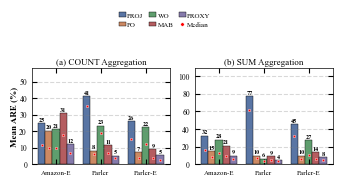

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
Y_SCALE = "linear"  

# 🚨 【极限排版控制】：在 3.5 英寸单栏塞下 30 根柱子，必须采用微缩参数
BAR_TEXT_FONTSIZE = 4.5      # IEEE 允许的图内最小字号通常为 4.5pt ~ 5.0pt
ROUND_TO_INT = True          # 强转为整型以缩短字符宽度，彻底避免水平重叠

DATASETS_CONFIG = {
    "Parler": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results"},
    "Parler-E": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results"},
    "Amazon-E": {"base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results"}
}

METHOD_MAP = {"UN": "PROJ", "PO": "PO", "WO": "WO", "MAB": "MAB", "8_POSSA": "PROXY", "POSS": "PROXY"}
DISPLAY_ORDER = ["PROJ", "PO", "WO", "MAB", "PROXY"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "ablation_combined_1x2_icde.pdf") # 命名更新为 icde

# ==========================================
# 2. IEEE / ICDE 极致紧凑单栏排版规范 (3.5 英寸)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",             # 🚨 必须是 serif，严禁使用 sans-serif
    "font.serif": ["Times New Roman"],  # 🚨 强制应用标准 Times New Roman
    "mathtext.fontset": "stix",         # 公式字体配齐
    "font.size": 6.0,                   # 全局基础字号下调
    "axes.labelsize": 6.5,
    "axes.titlesize": 6.5,              # (a) (b) 子图标题
    "legend.fontsize": 5.0,             # 图例需要极小
    "xtick.labelsize": 5.0,             # 极度压缩 X 轴数据集名称，防挤碰
    "ytick.labelsize": 5.5,
    "axes.linewidth": 0.5,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8
})

# ==========================================
# 3. 数据加载函数
# ==========================================
def load_data_for_mode(agg_mode):
    all_records = []
    csv_name = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        json_name = f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
        
        if display_name == "Amazon-E":
            json_name = f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
            
        csv_path = os.path.join(base_dir, "efficiency", csv_name)
        json_path = os.path.join(base_dir, json_name)
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            continue
            
        with open(json_path, 'r') as f:
            t_true_map = {k.replace(".graph", ""): float(v) for k, v in json.load(f).items()}
        
        df = pd.read_csv(csv_path)
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        df["T_true"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True).map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + 1e-9)
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name, "Method": row["method_display"],
                "AAE": row["mean"] * 100, "Median_AAE": row["median"] * 100 
            })
            
    df_plot = pd.DataFrame(all_records)
    if not df_plot.empty:
        df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
        df_plot = df_plot.sort_values(["Dataset", "Method"])
    return df_plot

# ==========================================
# 4. 绘制 1x2 横向紧凑单栏双图
# ==========================================
# 🚨 宽度严格锁定 3.5 英寸 (单栏)，高度压缩至 1.6 英寸实现黄金扁平比例
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.6), sharey=False)
palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

modes = ['count', 'sum']
titles = ['(a) COUNT Aggregation', '(b) SUM Aggregation']

for idx, mode in enumerate(modes):
    ax = axes[idx]
    df_plot = load_data_for_mode(mode)
    
    if df_plot.empty:
        ax.set_title(f"No Data for {mode}")
        continue

    # 绘制柱状图，降低 edgecolor 粗细以防柱子变黑
    sns.barplot(
        data=df_plot, x="Dataset", y="AAE", hue="Method", hue_order=DISPLAY_ORDER, 
        palette=palette, edgecolor="black", linewidth=0.3, ax=ax
    )

    ax.set_title(titles[idx], pad=3)
    ax.set_xlabel("")  
    
    # 网格线配置
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.3, color='gray')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}')) 
    
    # 刻度线强制朝内 (IEEE 标准)
    ax.tick_params(direction='in', which='both', top=True, right=True)
    
    if idx == 0:
        ax.set_ylabel("Mean ARE (%)", fontweight="bold", labelpad=1) 
    else:
        ax.set_ylabel("") 
        
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.35) 

    ax.get_legend().remove()

    datasets_order = df_plot["Dataset"].unique()
    for i, container in enumerate(ax.containers):
        method_name = DISPLAY_ORDER[i]
        for j, bar in enumerate(container):
            height = bar.get_height()
            if pd.isna(height) or height <= 0: continue
                
            x_pos = bar.get_x() + bar.get_width() / 2
            dataset_name = datasets_order[j]
            median_val = df_plot[(df_plot["Method"] == method_name) & (df_plot["Dataset"] == dataset_name)]["Median_AAE"].values[0]

            ax.plot(x_pos, median_val, marker='o', color='red', markersize=1.8, zorder=3, markeredgecolor='white', markeredgewidth=0.3)
            
            # 极限化简数值：去除小数
            text_str = f'{int(round(height))}' if ROUND_TO_INT else f'{height:.1f}'
            
            ax.annotate(text_str, xy=(x_pos, height), xytext=(0, 1), textcoords="offset points",
                        ha='center', va='bottom', fontsize=BAR_TEXT_FONTSIZE, fontweight='bold', color='black', rotation=0)

    ax.tick_params(axis='x', rotation=0)

# ==========================================
# 5. 全局图例与排版收尾
# ==========================================
handles, labels = axes[0].get_legend_handles_labels()
handles.append(mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=2.5, markeredgecolor='white', markeredgewidth=0.3))
labels.append('Median')

# 🚨 极限空间避让法则：在 3.5 宽的图片上，一排 6 个必定挤压/出界。
# 必须改为 ncol=3 (双行排版)，并极力压缩图例之间的 columnspacing。
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

# 物理榨取边距：top 下移给图例留空，bottom 和 left 极致收缩
plt.subplots_adjust(wspace=0.18, top=0.76, bottom=0.16, left=0.12, right=0.98)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ 符合 IEEE 单栏（3.5 英寸）极致并排的图表已成功导出: {out_pdf}")
plt.show()

✅ 符合 IEEE 极致紧凑规范的无死白图表已生成: /home/wangshuo/resource/paper_figuires/ablation_combined_1x2_icde.pdf


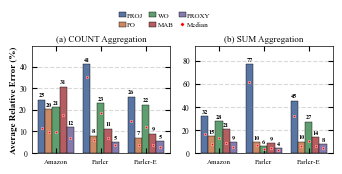

In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
Y_SCALE = "linear"  

BAR_TEXT_FONTSIZE = 4.5      
ROUND_TO_INT = True          

DATASETS_CONFIG = {
    "Parler": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results"},
    "Parler-E": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results"},
    "Amazon": {"base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results"}
}

METHOD_MAP = {"UN": "PROJ", "PO": "PO", "WO": "WO", "MAB": "MAB", "8_POSSA": "PROXY", "POSS": "PROXY"}
DISPLAY_ORDER = ["PROJ", "PO", "WO", "MAB", "PROXY"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "ablation_combined_1x2_icde.pdf") 

# ==========================================
# 2. IEEE / ICDE 极致紧凑单栏排版规范 (3.5 英寸)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",             
    "font.serif": ["Times New Roman"],  
    "mathtext.fontset": "stix",         
    "font.size": 6.0,                   
    "axes.labelsize": 6.5,
    "axes.titlesize": 6.5,              
    "legend.fontsize": 5.0,             
    "xtick.labelsize": 5.0,             
    "ytick.labelsize": 5.5,
    "axes.linewidth": 0.5,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8
})

# ==========================================
# 3. 数据加载函数
# ==========================================
def load_data_for_mode(agg_mode):
    all_records = []
    csv_name = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        json_name = f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
        
        if display_name == "Amazon":
            json_name = f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
            
        csv_path = os.path.join(base_dir, "efficiency", csv_name)
        json_path = os.path.join(base_dir, json_name)
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            continue
            
        with open(json_path, 'r') as f:
            t_true_map = {k.replace(".graph", ""): float(v) for k, v in json.load(f).items()}
        
        df = pd.read_csv(csv_path)
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        df["T_true"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True).map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + 1e-9)
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name, "Method": row["method_display"],
                "AAE": row["mean"] * 100, "Median_AAE": row["median"] * 100 
            })
            
    df_plot = pd.DataFrame(all_records)
    if not df_plot.empty:
        df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
        df_plot = df_plot.sort_values(["Dataset", "Method"])
    return df_plot

# ==========================================
# 4. 绘制 1x2 横向紧凑单栏双图
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.6), sharey=False)
palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

modes = ['count', 'sum']
titles = ['(a) COUNT Aggregation', '(b) SUM Aggregation']

for idx, mode in enumerate(modes):
    ax = axes[idx]
    df_plot = load_data_for_mode(mode)
    
    if df_plot.empty:
        ax.set_title(f"No Data for {mode}")
        continue

    sns.barplot(
        data=df_plot, x="Dataset", y="AAE", hue="Method", hue_order=DISPLAY_ORDER, 
        palette=palette, edgecolor="black", linewidth=0.3, ax=ax
    )

    ax.set_title(titles[idx], pad=3)
    ax.set_xlabel("")  
    
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.3, color='gray')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}')) 
    
    ax.tick_params(direction='in', which='both', top=True, right=True)
    
    if idx == 0:
        ax.set_ylabel("Average Relative Error (%)", fontweight="bold", labelpad=1) 
    else:
        ax.set_ylabel("") 
        
    ymin, ymax = ax.get_ylim()
    # 🚨 【核心修正1】: 将 1.35 改为了 1.15，大幅削减柱子上方没用的空白！
    ax.set_ylim(0, ymax * 1.15) 

    ax.get_legend().remove()

    datasets_order = df_plot["Dataset"].unique()
    for i, container in enumerate(ax.containers):
        method_name = DISPLAY_ORDER[i]
        for j, bar in enumerate(container):
            height = bar.get_height()
            if pd.isna(height) or height <= 0: continue
                
            x_pos = bar.get_x() + bar.get_width() / 2
            dataset_name = datasets_order[j]
            median_val = df_plot[(df_plot["Method"] == method_name) & (df_plot["Dataset"] == dataset_name)]["Median_AAE"].values[0]

            ax.plot(x_pos, median_val, marker='o', color='red', markersize=1.8, zorder=3, markeredgecolor='white', markeredgewidth=0.3)
            
            text_str = f'{int(round(height))}' if ROUND_TO_INT else f'{height:.1f}'
            
            # xytext=(0, 1.5) 表示文本仅比柱子高出 1.5个像素，极为紧凑
            ax.annotate(text_str, xy=(x_pos, height), xytext=(0, 1.5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=BAR_TEXT_FONTSIZE, fontweight='bold', color='black', rotation=0)

    ax.tick_params(axis='x', rotation=0)

# ==========================================
# 5. 全局图例与排版收尾
# ==========================================
handles, labels = axes[0].get_legend_handles_labels()
handles.append(mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=2.5, markeredgecolor='white', markeredgewidth=0.3))
labels.append('Median')

# 🚨 【核心修正2】: 将 bbox_to_anchor 的 y 值从 1.15 降到 1.08，把图例狠狠向下拉近！
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

# 🚨 【核心修正3】: 将 top 从 0.76 提升到了 0.83，让下方的柱状图向上扩张，吃掉没用的死白！
plt.subplots_adjust(wspace=0.18, top=0.83, bottom=0.16, left=0.12, right=0.98)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ 符合 IEEE 极致紧凑规范的无死白图表已生成: {out_pdf}")
plt.show()

✅ 符合 IEEE 极致紧凑、无加粗字体的规范图表已生成: /home/wangshuo/resource/paper_figuires/ablation_combined_1x2_icde.pdf


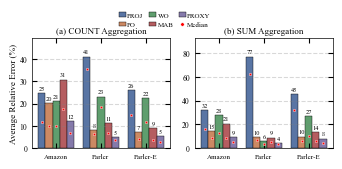

In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. 全局配置与路径                                          
# ==========================================
TARGET_BUDGET = 0.1  
Y_SCALE = "linear"  

BAR_TEXT_FONTSIZE = 4.5      
ROUND_TO_INT = True          

DATASETS_CONFIG = {
    "Parler": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_three/results"},
    "Parler-E": {"base_dir": "/home/wangshuo/resource/datasets/parler_data/dataset_test/results"},
    "Amazon": {"base_dir": "/home/wangshuo/resource/datasets/amazon_data/amazon_extend/results"}
}

METHOD_MAP = {"UN": "PROJ", "PO": "PO", "WO": "WO", "MAB": "MAB", "8_POSSA": "PROXY", "POSS": "PROXY"}
DISPLAY_ORDER = ["PROJ", "PO", "WO", "MAB", "PROXY"]

out_dir = "/home/wangshuo/resource/paper_figuires"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "ablation_combined_1x2_icde.pdf") 

# ==========================================
# 2. IEEE / ICDE 极致紧凑单栏排版规范 (3.5 英寸)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",             
    "font.serif": ["Times New Roman"],  # 🚨 严格强制 Times New Roman
    "mathtext.fontset": "stix",         
    "font.size": 6.0,                   
    "axes.labelsize": 6.5,
    "axes.titlesize": 6.5,              
    "legend.fontsize": 5.0,             
    "xtick.labelsize": 5.0,             
    "ytick.labelsize": 5.5,
    "axes.linewidth": 0.5,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8
})

# ==========================================
# 3. 数据加载函数
# ==========================================
def load_data_for_mode(agg_mode):
    all_records = []
    csv_name = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        json_name = f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
        
        if display_name == "Amazon":
            json_name = f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
            
        csv_path = os.path.join(base_dir, "efficiency", csv_name)
        json_path = os.path.join(base_dir, json_name)
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            continue
            
        with open(json_path, 'r') as f:
            t_true_map = {k.replace(".graph", ""): float(v) for k, v in json.load(f).items()}
        
        df = pd.read_csv(csv_path)
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        df["T_true"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True).map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + 1e-9)
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name, "Method": row["method_display"],
                "AAE": row["mean"] * 100, "Median_AAE": row["median"] * 100 
            })
            
    df_plot = pd.DataFrame(all_records)
    if not df_plot.empty:
        df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
        df_plot = df_plot.sort_values(["Dataset", "Method"])
    return df_plot

# ==========================================
# 4. 绘制 1x2 横向紧凑单栏双图
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.6), sharey=False)
palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

modes = ['count', 'sum']
titles = ['(a) COUNT Aggregation', '(b) SUM Aggregation']

for idx, mode in enumerate(modes):
    ax = axes[idx]
    df_plot = load_data_for_mode(mode)
    
    if df_plot.empty:
        ax.set_title(f"No Data for {mode}")
        continue

    sns.barplot(
        data=df_plot, x="Dataset", y="AAE", hue="Method", hue_order=DISPLAY_ORDER, 
        palette=palette, edgecolor="black", linewidth=0.3, ax=ax
    )

    ax.set_title(titles[idx], pad=3)
    ax.set_xlabel("")  
    
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.3, color='gray')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}')) 
    
    # 🚨 【核心修改】：强制纯黑轴线和封闭的向内刻度，符合 IEEE 学术要求
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.tick_params(direction='in', which='both', top=True, right=True, colors='black')
    
    if idx == 0:
        # 🚨 【核心修改】：移除了 fontweight="bold"，符合常规字重要求
        ax.set_ylabel("Average Relative Error (%)", color='black', labelpad=1) 
    else:
        ax.set_ylabel("") 
        
    ymin, ymax = ax.get_ylim()
    # 缩减柱子上方没用的空白
    ax.set_ylim(0, ymax * 1.15) 

    ax.get_legend().remove()

    datasets_order = df_plot["Dataset"].unique()
    for i, container in enumerate(ax.containers):
        method_name = DISPLAY_ORDER[i]
        for j, bar in enumerate(container):
            height = bar.get_height()
            if pd.isna(height) or height <= 0: continue
                
            x_pos = bar.get_x() + bar.get_width() / 2
            dataset_name = datasets_order[j]
            median_val = df_plot[(df_plot["Method"] == method_name) & (df_plot["Dataset"] == dataset_name)]["Median_AAE"].values[0]

            ax.plot(x_pos, median_val, marker='o', color='red', markersize=1.8, zorder=3, markeredgecolor='white', markeredgewidth=0.3)
            
            text_str = f'{int(round(height))}' if ROUND_TO_INT else f'{height:.1f}'
            
            # 🚨 【核心修改】：移除了 fontweight='bold'
            ax.annotate(text_str, xy=(x_pos, height), xytext=(0, 1.5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=BAR_TEXT_FONTSIZE, color='black', rotation=0)

    ax.tick_params(axis='x', rotation=0, colors='black')

# ==========================================
# 5. 全局图例与排版收尾
# ==========================================
handles, labels = axes[0].get_legend_handles_labels()
handles.append(mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=2.5, markeredgecolor='white', markeredgewidth=0.3))
labels.append('Median')

# 🚨 将图例紧凑地贴在图表上方
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

# 🚨 将绘图区向上推挤，吃掉无用的空白，呈现顶会特有的饱满排版
plt.subplots_adjust(wspace=0.18, top=0.85, bottom=0.16, left=0.12, right=0.98)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ 符合 IEEE 极致紧凑、无加粗字体的规范图表已生成: {out_pdf}")
plt.show()

1. 贪心方法

In [3]:
class Solution:
    def integerBreak(self, n: int) -> int:
        # 特殊情况处理：对于 n <= 3，必须拆分，最大乘积为 n - 1
        if n <= 3:
            return n - 1
        
        # 获取 n 除以 3 的商和余数
        quotient, remainder = divmod(n, 3)
        
        if remainder == 0:
            return 3 ** quotient
        elif remainder == 1:
            return 3 ** (quotient - 1) * 4
        else:  # remainder == 2
            return 3 ** quotient * 2

# 用于测试的代码
if __name__ == "__main__":
    sol = Solution()
    # 测试用例
    test_cases = [2, 3, 4, 10, 15, 30,50]
    for tc in test_cases:
        print(f"n = {tc:2d} -> 最大乘积: {sol.integerBreak(tc)}")

n =  2 -> 最大乘积: 1
n =  3 -> 最大乘积: 2
n =  4 -> 最大乘积: 4
n = 10 -> 最大乘积: 36
n = 15 -> 最大乘积: 243
n = 30 -> 最大乘积: 59049
n = 50 -> 最大乘积: 86093442


2. 动态规划

In [3]:
from typing import List, Tuple

class SolutionDP:
    def integerBreakWithTrace(self, n: int) -> Tuple[int, List[int]]:
        if n < 2:
            return 0, []
        
        # dp[i] 存储正整数 i 拆分后的最大乘积
        dp = [0] * (n + 1)
        # choice[i] 存储正整数 i 达到最大乘积时，第一步拆分出的最优因子 j
        choice = [0] * (n + 1)
        
        # 基础情况
        dp[1] = 0  # 1 无法拆分为至少两个正整数
        
        # 动态规划填表
        for i in range(2, n + 1):
            max_val = 0
            best_j = 0
            for j in range(1, i):
                # 选项 1：将 i 拆分为 j 和 i-j，且 i-j 不再继续拆分
                val_no_split = j * (i - j)
                # 选项 2：将 i 拆分为 j 和 i-j，且 i-j 继续拆分
                val_split = j * dp[i - j]
                
                current_max = max(val_no_split, val_split)
                if current_max > max_val:
                    max_val = current_max
                    best_j = j
            
            dp[i] = max_val
            choice[i] = best_j
            
        # 根据 choice 数组递归重建具体的拆分路径（所有因子）
        def reconstruct(val: int) -> List[int]:
            j = choice[val]
            # 如果剩余部分 (val - j) 不再拆分比继续拆分更好（或相等）
            if val - j >= dp[val - j]:
                return [j, val - j]
            else:
                return [j] + reconstruct(val - j)
                
        partition = reconstruct(n)
        return dp[n], partition

# 测试代码
if __name__ == "__main__":
    sol = SolutionDP()
    test_cases = [2, 8, 10,15,30,50]
    for tc in test_cases:
        max_product, factors = sol.integerBreakWithTrace(tc)
        print(f"输入 n = {tc:2d} -> 最大乘积: {max_product:2d}, 拆分出的因子路径: {factors}")

输入 n =  2 -> 最大乘积:  1, 拆分出的因子路径: [1, 1]
输入 n =  8 -> 最大乘积: 18, 拆分出的因子路径: [2, 3, 3]
输入 n = 10 -> 最大乘积: 36, 拆分出的因子路径: [2, 2, 3, 3]
输入 n = 15 -> 最大乘积: 243, 拆分出的因子路径: [3, 3, 3, 3, 3]
输入 n = 30 -> 最大乘积: 59049, 拆分出的因子路径: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
输入 n = 50 -> 最大乘积: 86093442, 拆分出的因子路径: [2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


请你做一个轻量级 AI CRM 商机跟进平台 MVP。
这个平台面向销售人员，主要用于管理客户、商机、会议纪要、承诺事项、任务和风险。
第一版不要求完整 CRM，但至少要包括：客户列表、商机列表、商机详情、会议纪要输入和 AI 识别结果。
AI 功能要求：输入一段销售会议纪要，系统能够识别我方承诺、客户方承诺、待办任务、风险和下一步建议。
请你先做 5 分钟产品规划，再使用 AI 工具进行 Vibe Coding，尽量在短时间内交付一个可运行 Demo。